<div dir="rtl" style="text-align: right;">

# פסטיבל Queuechella - דו"ח סימולציה בדידה

מחברת זו היא גם קוד הרצה וגם דו"ח מסכם לפרויקט בקורס סימולציה. המטרה היא להדגים מודל סימולציה בדידה מונחית-אירועים עבור פסטיבל Queuechella, תוך שימוש בשעון סימולציה, רשימת אירועים, תורים, משאבים, משתני מצב ומדדי פלט.

הדגש במחברת הוא על בחירות מידול פשוטות ושקופות שמתאימות לחומר הקורס: דגימה מתוך \(U(0,1)\), רפליקציות, רווחי סמך, דיוק יחסי והשוואה סטטיסטית בין המצב הקיים לבין חלופות במסגרת תקציב.

</div>


<div dir="rtl" style="text-align: right;">

## תיאור המערכת והנחות כלליות

Queuechella הוא פסטיבל מוזיקה בן יומיים. המבקרים מגיעים בקבוצות חברים, בזוגות או כיחידים, עוברים דרך כניסה, בוחרים פעילויות, ממתינים בתורים, מקבלים שירות או נכנסים להופעות, ולעיתים נוטשים תור כאשר ההמתנה ארוכה מדי.

המודל הוא סימולציה בדידה מפני שמצב המערכת משתנה רק בנקודות זמן מוגדרות: הגעת מבקר, הצטרפות לתור, התחלת שירות, סיום שירות, התחלת הופעה, סיום הופעה, נטישה וסיום יום. בין אירועים המצב נשאר קבוע ולכן ניתן לקדם את שעון הסימולציה ישירות לאירוע הבא.

המצב הקיים נבנה תחילה כדי ליצור בסיס להשוואה. רק לאחר שמודל הבסיס רץ ונבדק, מוגדרות חלופות שמחליפות פרמטרים בלבד, כך שכל התרחישים נמדדים באותה לוגיקת סימולציה.


- **זמני מעבר והליכה:** ההנחה היא שזמני המעבר וההליכה הפיזיים בין הבמות השונות, דוכני המזון והתחנות שווים לאפס (מעבר מיידי). ברגע שפעילות אחת מסתיימת, הישות מצטרפת מייד לתור של הפעילות הבאה שנבחרה.
</div>

<div dir="rtl" style="text-align: right;">

## הנחות מידול

הטבלה הבאה מרכזת הנחות שלא היו מפורטות באופן מלא בהנחיות או שנדרשו כדי להפוך את המערכת למודל ניתן להרצה. כל הנחה נשמרה פשוטה ככל האפשר כדי שהמודל יתאים לפרויקט בקורס סימולציה.

| הנחה | סיבה | סיכון | כיצד לעדכן |
|---|---|---|---|
| זמן שירות PhotoStation מבוסס על פונקציית הצפיפות הרשמית של המטלה | פונקציית הצפיפות הקטעית מופיעה בהוראות המטלה, וניתן להפוך את פונקציית ההתפלגות המצטברת לצורך דגימה | טעות בהעתקת הפונקציה תשפיע על זמני ההמתנה בעמדת הצילום | לבדוק את `sample_photo_station_service_time()` מול הוראות המטלה אם מתפרסמת גרסה מעודכנת |
| זמן שירות בכניסה נדגם כזמן חיובי פשוט | נדרש זמן טיפול כדי ליצור תור כניסה | עשוי להשפיע על עומס בשעות הבוקר | לעדכן את פונקציית הדגימה של כניסה אם יינתנו נתונים |
| MerchTent, FoodStand ו-BodyArt משתמשים בזמני שירות פשוטים | אין לכל התחנות מדגם היסטורי מלא | פישוט של שונות אמיתית בין נותני שירות | להחליף את דגימות השירות לפי נתוני אמת |
| קבוצות וזוגות נעים כישות אחת | מפשט את היישום ומאפשר חישוב הכנסות ושביעות רצון לפי מספר אנשים | אינו מתאר פיצול קבוצות | להוסיף ישויות משנה אם נדרש פירוט גבוה יותר |
| נטישה חלה רק בתורי תחנות שאינן הופעות | ההנחיות מדגישות נטישה בתורי שירות | עומס בבמות עשוי להיות מוערך ביתר | להוסיף נטישה גם לבמות אם ההנחיות דורשות |
| מבקר שנטש תחנה נחשב כאילו דילג עליה | מונע לולאות ניסיון אינסופיות | עשוי להפחית ביקוש חוזר | לשמור היסטוריית ניסיונות ולאפשר ניסיון חוזר מוגבל |
| ניקוי סוף יום מתבצע בשעה 20:00 | נדרש לאכוף את כללי הלינה והמשך ליום 2 | מבקרים באמצע שירות עשויים להיות מוסרים באופן חד | אם ההנחיות ישתנו, ניתן לאפשר סיום שירות לפני עזיבה |
| זמני מעבר והליכה פיזיים בין פעילויות מונחים כ-0 (מעבר מיידי) | הנחיות הפרויקט אינן מספקות קואורדינטות של פריסת הפסטיבל, מהירויות הליכה או מרחקים בין אזורים | עשוי להעריך יתר על המידה את העומס המיידי בתורים, ומייצג תרחיש קיצון שמרני לאורך התורים | אם תתקבל מפת הפסטיבל עם מרחקים, ניתן להגדיר מטריצת מרחקים ולחשב זמני מעבר לפי מהירות הליכה ממוצעת |

במסגרת ניקוי סוף יום, מבקרים שאינם זכאים להמשיך מוסרים מהמערכת בשעה 20:00. קבוצת חברים ממשיכה רק אם סומנה כלנה במקום, וזוג ממשיך ליום השני רק אם הגיע ביום הראשון ושביעות הרצון הממוצעת שלו גבוהה מ-7. למבקרים זכאים מנקים את מצב התור, השירות או הבמה הזמני, ולאחר מכן הם ממשיכים דרך אירוע `ACTIVITY_DECISION` רגיל ביום השני.

</div>

<div dir="rtl" style="text-align: right;">

## מבנה המודל הבדיד

היישום שומר על מבנה מונחה-עצמים קריא: ישויות מבקרים, משאבים, במות, אירועים, רשימת אירועים ואוסף סטטיסטיקות. זהו אינו מוצר תוכנה, אלא דרך מסודרת להציג סימולציה בדידה שניתן להסביר ולהגן עליה בקורס.

| רכיב | תפקיד במודל |
|---|---|
| ישות מבקר | שומרת סוג מבקר, גודל קבוצה, יום הגעה, שביעות רצון, מסלול וסטטוס |
| משאב | מייצג תחנות שירות עם קיבולת, תור, משתמשים פעילים וניצול |
| במה | מייצגת הופעות עם קיבולת, תור, מופע פעיל וקהל |
| אירוע | מייצג שינוי מצב בזמן מסוים בשעון הסימולציה |
| רשימת אירועים | תור עדיפויות שמחזיר בכל פעם את האירוע הקרוב ביותר |
| סטטיסטיקות | אוספות זמני המתנה, נטישות, הכנסות, ניצול ושביעות רצון |

מדדי הפלט המרכזיים הם שביעות רצון ממוצעת, זמן המתנה ממוצע ורווח נטו. מדדים משניים כמו נטישות, הכנסות וניצול משמשים להסבר התוצאות.

</div>


<div dir="rtl" style="text-align: right;">

## תרשים אירועים

התרשים מציג אילו אירועים עשויים לתזמן אירועים עתידיים. חצים מקווקווים היוצאים מ-`INIT` מייצגים תזמון התחלתי, והחץ המקווקו מ-`DAY_END` מתקיים רק עבור מבקרים הזכאים להמשיך ליום השני. שמות האירועים נשארים באנגלית משום שהם משמשים גם כמחרוזות פנימיות בקוד.

```mermaid
flowchart TD
    INIT((אתחול)) -.-> ARR[ARRIVAL<br/>הגעת מבקר]
    INIT -.-> SHOW_START[SHOW_START(stage)<br/>תחילת מופע Main/Side]
    INIT -.-> DAY_END[DAY_END<br/>סוף יום]
    INIT -.-> SIM_END[SIMULATION_END<br/>סיום סימולציה]

    ARR --> ENT_END[ENTRANCE_SERVICE_END<br/>סיום כניסה]
    ENT_END --> ENT_END
    ENT_END --> ACT[ACTIVITY_DECISION<br/>החלטת פעילות]

    ACT --> SERV_END[SERVICE_END<br/>סיום שירות בתחנה]
    SERV_END --> SERV_END
    SERV_END --> ACT
    SERV_END --> BODYART_BREAK_END[BODYART_BREAK_END<br/>סיום הפסקת אמן BodyArt]
    BODYART_BREAK_END --> SERV_END

    ACT --> Q_ABANDON[QUEUE_ABANDON<br/>נטישת תור]
    Q_ABANDON --> ACT

    SHOW_START --> SHOW_END[SHOW_END(stage)<br/>סיום מופע Main/Side]
    SHOW_END --> SHOW_START
    SHOW_END --> ACT
    SHOW_START --> EARLY[SHOW_EARLY_LEAVE<br/>עזיבה מוקדמת ממופע]
    ACT --> EARLY
    EARLY --> EARLY
    EARLY --> ACT

    ACT --> DJ_EXIT[DJ_STAGE_EXIT<br/>יציאה מ-DJ]
    DJ_EXIT --> DJ_EXIT
    DJ_EXIT --> ACT

    ACT --> FOOD_ORDER_END[FOOD_ORDER_END<br/>סיום לקיחת הזמנה]
    FOOD_ORDER_END --> FOOD_ORDER_END
    FOOD_ORDER_END --> FOOD_PREP_END[FOOD_PREP_END<br/>סיום הכנת אוכל]
    FOOD_PREP_END --> FOOD_EATING_END[FOOD_EATING_END<br/>סיום אכילה]
    FOOD_EATING_END --> ACT

    DAY_END -.->|זכאי ליום 2| ACT
```

חמש זרימות טיפול עיקריות:

1. `ARRIVAL`: יצירת ישות, הצטרפות לתור הכניסה והתחלת טיפול מיידית כאשר פקיד פנוי.
2. `SERVICE_END`: שחרור משאב בתחנה רגילה, עדכון תוצאת הפעילות והתחלת שירות לממתין הבא.
3. `ACTIVITY_DECISION`: לאחר סיום פעילות, בודק פעם אחת לכל ישות בכל יום האם לבחור בארוחת צהריים, ולאחר מכן מנתב לפעילות הבאה.
4. `FOOD_ORDER_END`, `FOOD_PREP_END`, `FOOD_EATING_END`: הפרדה בין סיום הקופה, סיום הכנת המנה וסיום האכילה.
5. `SHOW_START(stage)` ו-`SHOW_END(stage)`: אירועים כלליים שבהם שם הבמה נשמר בפרמטר `target`.

</div>


<div dir="rtl" style="text-align: right;">

## טעינת ספריות, פונקציות עזר ונתוני קלט

בלוק הקוד הבא טוען ספריות, מגדיר פונקציות עזר להצגת טבלאות בדו"ח, ובודק שקובץ הנתונים `samples_for_simulation.xlsx` נמצא בתיקיית ההרצה. אם הקובץ חסר ב-Colab, יש להעלות אותו לאותה תיקייה לפני הרצה.

</div>


In [166]:
# =============================================================================
# BLOCK 1: SIMULATION LIBRARIES AND GLOBAL CONFIGURATION
# =============================================================================

import math
import random
import heapq
import statistics
from dataclasses import dataclass, field
from collections import defaultdict, deque
from pathlib import Path
from zipfile import ZipFile
import xml.etree.ElementTree as ET

# Data analysis and scientific computing
try:
    import pandas as pd
except ImportError:
    pd = None

try:
    import numpy as np
except ImportError:
    np = None

try:
    import scipy.stats as stats
except ImportError:
    stats = None

# Visualization libraries
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    plt = None
    sns = None

# IPython Display for HTML Reports in Colab
try:
    from IPython.display import display, HTML
except ImportError:
    display = None
    HTML = None

def report_panel(title, body):
    """Render a clean RTL academic report panel."""
    html = f"""
    <div dir="rtl" style="direction:rtl;text-align:right;background:#ffffff;color:#1f2937;border:1px solid #d1d5db;
                border-radius:4px;padding:12px;font-family:Arial, sans-serif;line-height:1.55;margin:8px 0;">
      <div style="color:#111827;font-weight:600;margin-bottom:6px;font-size:15px;">{title}</div>
      <div>{body}</div>
    </div>
    """
    if display and HTML:
        display(HTML(html))
    else:
        print(title)
        print(body)


def report_table(rows, title="טבלה"):
    """Render a compact RTL academic report table."""
    if pd is not None:
        df = pd.DataFrame(rows)
        table_html = df.to_html(index=False, border=0, classes="report-table")
        style = """
        <style>
        table.report-table {border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; font-size: 13px; color: #1f2937; direction: rtl;}
        table.report-table th {background: #f3f4f6; border: 1px solid #d1d5db; padding: 6px 8px; text-align: right; font-weight: 600;}
        table.report-table td {border: 1px solid #e5e7eb; padding: 6px 8px; vertical-align: top; text-align: right;}
        table.report-table tr:nth-child(even) {background: #fafafa;}
        </style>
        """
        report_panel(title, style + table_html)
    else:
        print(title)
        for row in rows:
            print(row)


# Global File Path
DATA_FILE = Path("samples_for_simulation.xlsx")

# Simulation Time Constants (in minutes)
# Day 1: 09:00 (Minute 0.0) to 20:00 (Minute 660.0)
# Day 2: 09:00 (Minute 1440.0) to 20:00 (Minute 2100.0)
DAY_STARTS = [0.0, 1440.0]
DAY_ENDS = [660.0, 2100.0]
SIM_END = 2100.0
EPS = 1e-12       # Epsilon to prevent division by zero


def read_xlsx_first_column(path: Path, sheet_name: str) -> list:
    if not path.exists():
        raise FileNotFoundError(
            f"Required file '{path.name}' not found. Please upload it to your Colab runtime."
        )

    if pd is not None:
        df = pd.read_excel(path, sheet_name=sheet_name)
        return [float(x) for x in df.iloc[:, 0].dropna().tolist()]

    # Fallback XML parsing mechanism
    ns = {
        "a": "http://schemas.openxmlformats.org/spreadsheetml/2006/main",
        "r": "http://schemas.openxmlformats.org/officeDocument/2006/relationships",
    }
    with ZipFile(path) as zf:
        shared = []
        if "xl/sharedStrings.xml" in zf.namelist():
            root = ET.fromstring(zf.read("xl/sharedStrings.xml"))
            for si in root.findall("a:si", ns):
                shared.append("".join(t.text or "" for t in si.findall(".//a:t", ns)))

        workbook = ET.fromstring(zf.read("xl/workbook.xml"))
        rels = ET.fromstring(zf.read("xl/_rels/workbook.xml.rels"))
        relmap = {rel.attrib["Id"]: rel.attrib["Target"] for rel in rels}

        sheet_path = None
        for sheet in workbook.findall("a:sheets/a:sheet", ns):
            if sheet.attrib["name"] == sheet_name:
                rid = sheet.attrib["{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id"]
                sheet_path = "xl/" + relmap[rid].lstrip("/")
                break

        if sheet_path is None:
            raise ValueError(f"Sheet name not found: {sheet_name}")

        root = ET.fromstring(zf.read(sheet_path))
        values = []
        for row in root.findall("a:sheetData/a:row", ns)[1:]:
            cell = row.find("a:c", ns)
            if cell is None: continue
            value = cell.find("a:v", ns)
            if value is None: continue
            raw = value.text
            if cell.attrib.get("t") == "s":
                raw = shared[int(raw)]
            values.append(float(raw))
        return values

def load_and_plot_data():
    """
    Loads the empirical datasets.
    """
    # Load raw data from Excel sheets
    datasets = {
        "FriendsGroup Interarrival": read_xlsx_first_column(DATA_FILE, "FriendsGroup_arrival_intervals"),
        "MainStage Duration": read_xlsx_first_column(DATA_FILE, "MainStage_concert_duration")
    }
    return datasets

# Execute code to extract data
historical_data = load_and_plot_data()


<div dir="rtl" style="text-align: right;">

## מידול קלט מתוך הנתונים

בחלק זה נאמדים פרמטרים משני גיליונות Excel שסופקו לפרויקט. מכיוון שזהו פרויקט בקורס סימולציה, מודלי הקלט הסופיים משתמשים במכוון בהתפלגויות ושיטות דגימה שנלמדו בקורס.

* עבור זמני ביניים של FriendsGroup נבחרה התפלגות מעריכית, עם תוחלת שנאמדת מממוצע המדגם. הדגימה נעשית בשיטת Inverse Transform.
* עבור משך הופעת MainStage נבחרה התפלגות נורמלית, עם ממוצע וסטיית תקן מהמדגם. הדגימה נעשית בשיטת Box-Muller, עם הגנה מפני ערכים לא חיוביים.

בדיקת ההתאמה המוצגת היא בדיקת KS פשוטה עבור המודל שנבחר בלבד. היא משמשת לתיעוד סביר של בחירת הקלט, ולא לבחירת מודל מורכבת.

</div>


In [167]:
import numpy as np
try:
    import scipy.stats as stats
except ImportError:
    stats = None

def fit_and_test_distributions(datasets: dict):
    """
    Fits Exponential and Normal distributions to the empirical data.
    Calculates Log-Likelihood, and conducts a Kolmogorov-Smirnov test.
    Plots both PDF and CDF overlays for complete academic validation.
    """
    if plt is None or sns is None or stats is None:
        print("Required scientific/plotting libraries are missing. Cannot run analysis.")
        return

    sns.set_theme(style="whitegrid")

    # Create a single figure with 2 rows and 2 columns for all plots
    fig, axes = plt.subplots(len(datasets), 2, figsize=(18, 6 * len(datasets))) # Adjust figsize as needed
    # Flatten axes if there's only one row for easier indexing
    if len(datasets) == 1:
        axes = np.expand_dims(axes, axis=0)

    plot_row_idx = 0 # To keep track of which row we are plotting to

    for name, data in datasets.items():
        data_arr = np.array(data)
        n = len(data_arr)

        # --- 1. Statistical Fitting ---
        # Fit Exponential: returns (loc, scale) where lambda = 1/scale. We fix loc=0 for standard expo.
        exp_loc, exp_scale = stats.expon.fit(data_arr, floc=0)
        exp_lambda = 1.0 / exp_scale

        # Fit Normal: returns (mu, sigma)
        norm_mu, norm_sigma = stats.norm.fit(data_arr)

        # --- 2. Calculate Fitness Metrics (Log-Likelihood) ---
        # Exponential metrics
        exp_log_lik = np.sum(stats.expon.logpdf(data_arr, loc=exp_loc, scale=exp_scale))

        # Normal metrics
        norm_log_lik = np.sum(stats.norm.logpdf(data_arr, loc=norm_mu, scale=norm_sigma))

        # --- 3. Hypothesis Testing (Kolmogorov-Smirnov Test) ---
        exp_ks_stat, exp_ks_p = stats.kstest(data_arr, 'expon', args=(exp_loc, exp_scale))
        norm_ks_stat, norm_ks_p = stats.kstest(data_arr, 'norm', args=(norm_mu, norm_sigma))

        # --- 4. Print Text Analysis (To be used for your report text) ---
        print("=" * 60)
        print(f"ANALYSIS REPORT FOR: {name}")
        print("=" * 60)
        print(f"Exponential Distribution:")
        print(f"  Estimated Rate (lambda): {exp_lambda:.5f}")
        print(f"  Log-Likelihood: {exp_log_lik:.2f}")
        print(f"  KS Test Statistic: {exp_ks_stat:.4f} | p-value: {exp_ks_p:.5f}")
        print("-" * 40)
        print(f"Normal Distribution:")
        print(f"  Estimated Mean (mu): {norm_mu:.4f}")
        print(f"  Estimated StdDev (sigma): {norm_sigma:.4f}")
        print(f"  Log-Likelihood: {norm_log_lik:.2f}")
        print(f"  KS Test Statistic: {norm_ks_stat:.4f} | p-value: {norm_ks_p:.5f}")
        print("\n")

        # --- 5. Generate Dual Academic Plots (PDF and CDF) ---
        x_eval = np.linspace(min(data_arr), max(data_arr), 500)

        # Plot A: Histogram and Theoretical Densities (PDF)
        sns.histplot(data_arr, stat="density", bins=20, alpha=0.4, color="gray", edgecolor="black", label="Empirical Data", ax=axes[plot_row_idx, 0])
        axes[plot_row_idx, 0].plot(x_eval, stats.expon.pdf(x_eval, loc=exp_loc, scale=exp_scale), 'r-', lw=2, label=f"Exponential (λ={exp_lambda:.3f})")
        axes[plot_row_idx, 0].plot(x_eval, stats.norm.pdf(x_eval, loc=norm_mu, scale=norm_sigma), 'b--', lw=2, label=f"Normal (μ={norm_mu:.1f}, σ={norm_sigma:.1f})")
        axes[plot_row_idx, 0].set_title(f"{name} - Histogram & PDF Overlay", fontsize=12, fontweight='bold')
        axes[plot_row_idx, 0].set_xlabel("Value")
        axes[plot_row_idx, 0].set_ylabel("Density")
        axes[plot_row_idx, 0].legend()

        # Plot B: Empirical and Theoretical CDFs
        # Sort data for empirical CDF plotting
        x_sorted = np.sort(data_arr)
        y_ecdf = np.arange(1, n + 1) / n
        axes[plot_row_idx, 1].scatter(x_sorted, y_ecdf, color="black", s=15, alpha=0.6, label="Empirical CDF", zorder=3)
        axes[plot_row_idx, 1].plot(x_eval, stats.expon.cdf(x_eval, loc=exp_loc, scale=exp_scale), 'r-', lw=2, label="Theoretical Exponential")
        axes[plot_row_idx, 1].plot(x_eval, stats.norm.cdf(x_eval, loc=norm_mu, scale=norm_sigma), 'b--', lw=2, label="Theoretical Normal")
        axes[plot_row_idx, 1].set_title(f"{name} - Empirical & Theoretical CDFs", fontsize=12, fontweight='bold')
        axes[plot_row_idx, 1].set_xlabel("Value")
        axes[plot_row_idx, 1].set_ylabel("CDF")
        axes[plot_row_idx, 1].legend()

        plot_row_idx += 1

    plt.tight_layout()
    plt.show()

# Run the complete analysis on the historical data
fit_and_test_distributions(historical_data)

# ============================================================================
# EXTRACT FITTED PARAMETERS FOR THE SAMPLER (global variables)
# ============================================================================
# These globals are used by the static Sampler class methods:
#   - sample_friends_interarrival() uses frieds_group_interarrival_rate
#   - sample_mainstage_duration() uses main_stage_duration_mu, main_stage_duration_sigma

if stats is not None and np is not None:
    _friends_data = np.array(historical_data["FriendsGroup Interarrival"])
    _exp_loc, _exp_scale = stats.expon.fit(_friends_data, floc=0)
    frieds_group_interarrival_rate = 1.0 / _exp_scale  # lambda for exponential

    _main_data = np.array(historical_data["MainStage Duration"])
    main_stage_duration_mu, main_stage_duration_sigma = stats.norm.fit(_main_data)

    print(f"Fitted parameters extracted:")
    print(f"  frieds_group_interarrival_rate (λ) = {frieds_group_interarrival_rate:.5f}")
    print(f"  main_stage_duration_mu = {main_stage_duration_mu:.4f}")
    print(f"  main_stage_duration_sigma = {main_stage_duration_sigma:.4f}")
else:
    # Fallback defaults if scipy not available
    frieds_group_interarrival_rate = 0.1
    main_stage_duration_mu = 45.0
    main_stage_duration_sigma = 10.0
    print("WARNING: scipy not available, using default Sampler parameters")


<div dir="rtl" style="text-align: right;">

### ניתוח סטטיסטי של התאמת ההתפלגויות (מבחן Kolmogorov-Smirnov)

על מנת לוודא שההתפלגויות התיאורטיות שבחרנו אכן מייצגות נאמנה את הנתונים ההיסטוריים, ביצענו אמידת פרמטרים בשיטת הנראות המרבית (MLE) ומבחני התאמה מסוג **Kolmogorov-Smirnov (KS Test)** ברמת מובהקות סטנדרטית של **$\alpha = 0.05$** (רמת ביטחון של 95%).

שערוריית ההתאמה מבוססת על השערת האפס ($H_0$) לפיה הנתונים האמפיריים מגיעים מההתפלגות התיאורטית שנבחנה. אנו נרצה לקבל ערך $p\text{-value} > 0.05$ על מנת לא לדחות את התאמת ההתפלגות.

#### 1. זמני הגעה של קבוצות חברים (`FriendsGroup Interarrival`)
* **התפלגות מועמדת:** מעריכית (Exponential) עם קצב אומד $\lambda = 0.72927$ (תוחלת של כ-1.37 דקות).
* **תוצאת המבחן:** $p\text{-value} = 0.391$ (סטטיסטי מבחן $D = 0.088$).
* **החלטה:** מכיוון ש-$p\text{-value} = 0.391 > 0.05$, **לא דוחים את השערת האפס ($H_0$)**. ההתפלגות המעריכית מתקבלת כהתאמה טובה ומובהקת לנתוני ההגעה של הקבוצות. 

#### 2. משך ההופעות בבמה המרכזית (`MainStage Duration`)
* **התפלגות מועמדת:** נורמלית (Normal) עם ממוצע $\mu = 45.90$ דקות וסטיית תקן $\sigma = 8.93$ דקות.
* **תוצאת המבחן:** $p\text{-value} = 0.229$ (סטטיסטי מבחן $D = 0.102$).
* **החלטה:** מכיוון ש-$p\text{-value} = 0.229 > 0.05$, **לא דוחים את השערת האפס ($H_0$)**. ההתפלגות הנורמלית מתקבלת כהתאמה טובה ומובהקת למשך ההופעות בבמה הראשית.
</div>


# אלגוריתמי דגימה


<div dir="rtl" style="text-align: right;">


כל הדגימות בסימולציה נבנות מתוך \(U(0,1)\), בהתאם לשיטות שנלמדו בקורס. אין שימוש בקריאות דגימה מוכנות של NumPy או SciPy עבור יצירת משתני הסימולציה.

כל פונקציות הדגימה הייחודיות של המודל מרוכזות במחלקת `Sampler`; מחלקת הסימולציה משתמשת בהן אך אינה מגדירה נוסחאות דגימה.

| מושג מהקורס | שימוש בסימולציה | הסבר קצר |
|---|---|---|
| Inverse Transform | זמני ביניים מעריכיים של FriendsGroup וזמן שירות PhotoStation לפי צפיפות קטעית | למעריכית משתמשים ב-\(X=-\mu\ln(1-U)\); בעמדת הצילום משתמשים בהופכי של פונקציית ההתפלגות המצטברת הרשמית |
| Box-Muller | דגימה נורמלית | יצירת משתנה נורמלי מתוך שני משתנים אחידים |
| Acceptance-Rejection | משך שהייה ב-DJStage | הצעת ערך בתחום ובחינתו לפי פונקציית צפיפות נתונה |
| Composition | בחירת פעילות או החלטה דיסקרטית | בחירה לפי הסתברויות מצטברות |
| Bernoulli | החלטות כן/לא | בדיקה אם \(U<p\) |
| Uniform | זמני שירות פשוטים ודגימות בסיס | המרה ליניארית של \(U(0,1)\) לתחום רצוי |

זמן השירות בעמדת הצילום מודל לפי פונקציית הצפיפות הקטעית המופיעה בהוראות המטלה. מאחר שניתן לחשב את פונקציית ההתפלגות המצטברת ולהפוך אותה, הדגימה בוצעה באמצעות שיטת הטרנספורם ההופכי.

</div>




## 1. משך השירות בעמדת הצילום (PhotoStation)

פונקציית הצפיפות של זמן השירות בעמדת הצילום מוגדרת כפונקציה קטועה:

$$f_{\text{photo}}(x)=\begin{cases}\frac{x}{6},&1\le x<2\\ \frac{x}{5}+\frac{1}{8},&2\le x<3\\ \frac{1}{8},&3\le x<4\end{cases}$$

#### פיתוח פונקציית ההתפלגות המצטברת $F(x)$

* **עבור התחום $1 \le x < 2$:**

$$F(x) = \int_{1}^{x} \frac{t}{6} dt = \left[ \frac{t^2}{12} \right]_{1}^{x} = \frac{x^2 - 1}{12}$$


$$F(2) = \frac{2^2 - 1}{12} = \frac{3}{12} = 0.25$$


* **עבור התחום $2 \le x < 3$:**

$$F(x) = 0.25 + \int_{2}^{x} \left(\frac{t}{5} + \frac{1}{8}\right) dt = 0.25 + \left[ \frac{t^2}{10} + \frac{t}{8} \right]_{2}^{x}$$


$$F(x) = 0.25 + \left(\frac{x^2}{10} + \frac{x}{8}\right) - \left(\frac{4}{10} + \frac{2}{8}\right) = \frac{x^2}{10} + \frac{x}{8} - 0.4$$


$$F(3) = \frac{3^2}{10} + \frac{3}{8} - 0.4 = 0.9 + 0.375 - 0.4 = 0.875$$


* **עבור התחום $3 \le x \le 4$:**

$$F(x) = 0.875 + \int_{3}^{x} \frac{1}{8} dt = 0.875 + \left[ \frac{t}{8} \right]_{3}^{x} = 0.875 + \frac{x}{8} - \frac{3}{8} = \frac{x}{8} + 0.5$$


$$F(4) = \frac{4}{8} + 0.5 = 1.0$$



#### פונקציית ההתפלגות המצטברת המלאה $F_{\text{photo}}(x)$

$$F_{\text{photo}}(x)=\begin{cases}\frac{x^2 - 1}{12},&1\le x<2\\ \frac{x^2}{10} + \frac{x}{8} - 0.4,&2\le x<3\\ \frac{x}{8} + 0.5,&3\le x\le 4\end{cases}$$

#### היפוך הפונקציה והשוואה לערך אקראי $U \sim U(0,1)$

1. **עבור התחום $0 \le U < 0.25$:**

$$U = \frac{x^2 - 1}{12} \implies 12U = x^2 - 1 \implies x = \sqrt{12U + 1}$$


2. **עבור התחום $0.25 \le U < 0.875$:**

$$U = \frac{x^2}{10} + \frac{x}{8} - 0.4 \implies \frac{1}{10}x^2 + \frac{1}{8}x - (0.4 + U) = 0$$



נשתמש בנוסחת השורשים:

$$x = \frac{-0.125 + \sqrt{0.015625 + 0.4(0.4 + U)}}{0.2} = \frac{-0.125 + \sqrt{0.4U + 0.175625}}{0.2}$$


3. **עבור התחום $0.875 \le U \le 1$:**

$$U = \frac{x}{8} + 0.5 \implies U - 0.5 = \frac{x}{8} \implies x = 8(U - 0.5)$$



#### פונקציית הדגימה הסופית $F^{-1}_{\text{photo}}(U)$

$$F^{-1}_{\text{photo}}(U)=\begin{cases}\sqrt{12U + 1},&0\le U<0.25\\ \frac{-0.125 + \sqrt{0.4U + 0.175625}}{0.2},&0.25\le U<0.875\\ 8(U - 0.5),&0.875\le U\le 1\end{cases}$$

> **אלגוריתם דגימה:**
> 1. דגום מספר אקראי $U \sim U(0,1)$
> 2. אם $U < 0.25$, החזר:
> 
> $$x = \sqrt{12U + 1}$$
> 
> 
> 3. אם $U < 0.875$, החזר:
> 
> $$x = \frac{-0.125 + \sqrt{0.4U + 0.175625}}{0.2}$$
> 
> 
> 4. אחרת, החזר:
> 
> $$x = 8(U - 0.5)$$
> 
> 
> 
> 

---

## 2. משך השירות בעמדת טעינת הטלפונים (ChargingStation)

פונקציית הצפיפות עבור משך הטעינה מוגדרת כפונקציה מעריכית מוזזת עם פרמטר $\alpha$ התלוי באחוז הסוללה ההתחלתי $b$:

$$f(t) = \frac{\alpha}{40^{\alpha}}(40-t)^{\alpha-1}, \quad 0\le t\le40, \quad \alpha=\frac{100}{100-b}$$

#### פיתוח פונקציית ההתפלגות המצטברת $F(t)$

$$F(t) = \int_{0}^{t} \frac{\alpha}{40^{\alpha}}(40-k)^{\alpha-1} dk$$


נציב $40-k = s \implies dk = -ds$:


$$F(t) = \frac{\alpha}{40^{\alpha}} \int_{40}^{40-t} -s^{\alpha-1} ds = \frac{\alpha}{40^{\alpha}} \int_{40-t}^{40} s^{\alpha-1} ds$$

$$F(t) = \frac{\alpha}{40^{\alpha}} \left[ \frac{s^{\alpha}}{\alpha} \right]_{40-t}^{40} = \frac{1}{40^{\alpha}} \left( 40^{\alpha} - (40-t)^{\alpha} \right)$$

$$F(t) = 1 - \left(\frac{40-t}{40}\right)^{\alpha}$$

#### היפוך הפונקציה והשוואה לערך אקראי $U \sim U(0,1)$

$$U = 1 - \left(\frac{40-t}{40}\right)^{\alpha} \implies 1 - U = \left(\frac{40-t}{40}\right)^{\alpha}$$

$$(1 - U)^{1/\alpha} = \frac{40-t}{40} \implies 40(1 - U)^{1/\alpha} = 40 - t \implies t = 40 \left(1 - (1 - U)^{1/\alpha}\right)$$


מכיוון ש-$U \sim U(0,1)$, מתקיים שגם $(1-U) \sim U(0,1)$. לכן פונקציית הדגימה הסופית היא:


$$F^{-1}_{\text{charge}}(U) = 40 \left(1 - U^{1/\alpha}\right)$$

> **אלגוריתם דגימה:**
> 1. דגום מספר אקראי $U \sim U(0,1)$
> 2. החזר:
> 
> $$t = 40 \left(1 - U^{1/\alpha}\right)$$
> 
> 
> 
>


---

## 3. דגימה בשיטת קבלה-דחייה (Acceptance-Rejection): משך סט די-ג'יי (DJ Duration)

פונקציית הצפיפות $f(x)$ עבור משך הנגינה של הדי-ג'יי מוגדרת כפונקציה קטועה:

$$f(x) = \begin{cases} 
\frac{x - 20}{600}, & 20 \le x \le 40 \\ 
\frac{60 - x}{600} + \frac{1}{30}, & 40 < x \le 50 \\ 
\frac{60 - x}{600}, & 50 < x \le 60 \\
0, & \text{else}
\end{cases}$$

####  מציאת הערך המקסימלי של הפונקציה

כדי למצוא את החסם העליון, נבדוק את ערכי הפונקציה בקצוות התחומים ונקודות הקיצון:

* **תחום א':** בנקודה $x = 40$ מתקבל:

$$f(40) = \frac{40 - 20}{600} = \frac{20}{600} = \frac{1}{30}$$


* **תחום ב' (מקסימום):** בנקודה $x = 40$ מתקבל:

$$f(40) = \frac{60 - 40}{600} + \frac{1}{30} = \frac{20}{600} + \frac{1}{30} = \frac{1}{30} + \frac{1}{30} = \frac{2}{30} = \frac{1}{15}$$


* **תחום ג':** בנקודה $x = 50$ מתקבל:

$$f(50) = \frac{60 - 50}{600} = \frac{10}{600} = \frac{1}{60}$$



> **מסקנה:** הערך המקסימלי של הפונקציה בתחום $20 \le x \le 60$ הוא $t(x) = \frac{1}{15}$.

####  הגדרת פונקציות העזר

* **פונקציית ההצעה $r(x)$:** נבחר התפלגות אחידה רציפה בתחום:

$$r(x) \sim U_c(20, 60) \implies r(x) = \frac{1}{60 - 20} = \frac{1}{40}$$



---

###  אלגוריתם דגימה  

1. **דגום ערך מוצע $Y$ מתוך פונקציית ההצעה $r(x)$:**

$$Y \sim r(x) \sim U_c(20, 60)$$


2. **דגום מספר אקראי $U$ מתוך התפלגות אחידה סטנדרטית:**

$$U \sim U_c(0, 1)$$


3. **בדיקת תנאי קבלה:**
אם מתקיים:

$$U \le \frac{f(Y)}{t(Y)} \implies U \le \frac{f(Y)}{1/15} \implies U \le 15 \cdot f(Y)$$



**החזר את $Y$**. (אחרת, דחה את הערך וחזור לשלב 1).

In [168]:
# Sampler Class
class Sampler:

    # Queue to store the second value from Box-Muller, if generated
    _box_muller_extra = deque()

    # u
    @staticmethod
    def u():
        eps_val = 1e-12
        return min(max(random.random(), eps_val), 1.0 - eps_val)

    # uniform
    @staticmethod
    def uniform(a, b):
        return a + (b - a) * Sampler.u()

    # bernoulli
    @staticmethod
    def bernoulli(p):
        return Sampler.u() < p

    # discrete_uniform
    @staticmethod
    def discrete_uniform(a, b):
        return a + int(math.floor((b - a + 1) * Sampler.u()))

    # exponential_inverse
    @staticmethod
    def exponential_inverse(mean):
        return -mean * math.log(1.0 - Sampler.u())

    # discrete_choice_composition
    @staticmethod
    def discrete_choice_composition(weighted_items):
        total = sum(weight for _, weight in weighted_items)
        threshold = Sampler.u() * total
        cumulative = 0.0
        for item, weight in weighted_items:
            cumulative += weight
            if threshold <= cumulative:
                return item
        return weighted_items[-1][0]

    # normal_box_muller
    @staticmethod
    def normal_box_muller(mean, std):
        if Sampler._box_muller_extra:
            return mean + std * Sampler._box_muller_extra.popleft()

        u1 = Sampler.u()
        u2 = Sampler.u()

        # Box-Muller transform
        z0 = math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)
        z1 = math.sqrt(-2.0 * math.log(u1)) * math.sin(2.0 * math.pi * u2)

        # Store z1 for the next call
        Sampler._box_muller_extra.append(z1)

        # Scale and shift z0
        return mean + std * z0

    # check_in_duration
    @staticmethod
    def check_in_duration():
        return Sampler.uniform(1.5, 3.0)

    # check_out_duration
    @staticmethod
    def check_out_duration():
        return Sampler.exponential_inverse(2.0)

    # sample_friends_interarrival
    @staticmethod
    def sample_friends_interarrival():
        global frieds_group_interarrival_rate
        return Sampler.exponential_inverse(1.0 / frieds_group_interarrival_rate) # mean is 1/lambda

    # couple_interarrival_time
    @staticmethod
    def couple_interarrival_time():
        return Sampler.exponential_inverse(1.0)

    # single_interarrival_time
    @staticmethod
    def single_interarrival_time():
        return Sampler.exponential_inverse(660.0 / 500.0)

    # sample_mainstage_duration
    @staticmethod
    def sample_mainstage_duration():
        global main_stage_duration_mu, main_stage_duration_sigma
        # Ensure duration is not negative
        return max(10.0, Sampler.normal_box_muller(main_stage_duration_mu, main_stage_duration_sigma))

    # destage_duration
    @staticmethod
    def destage_duration():
        return Sampler.uniform(20.0, 30.0)

    # dj_density
    @staticmethod
    def dj_density(x):
        if 20.0 <= x <= 40.0:
            return (x - 20.0) / 600.0
        elif 40.0 < x <= 50.0:
            return ((60.0 - x) / 600.0) + (1.0 / 30.0)
        elif 50.0 < x <= 60.0:
            return (60.0 - x) / 600.0
        return 0.0

    # sample_dj_duration_acceptance_rejection
    @staticmethod
    def sample_dj_duration_acceptance_rejection():
        max_density = 1.0 / 15.0
        while True:
            x = Sampler.uniform(20.0, 60.0)
            if Sampler.u() <= Sampler.dj_density(x) / max_density:
                return x

    # photo_density
    @staticmethod
    def photo_density(x):
        if 1.0 <= x < 2.0:
            return x / 6.0
        elif 2.0 <= x < 3.0:
            return x / 5.0 + 1.0 / 8.0
        elif 3.0 <= x < 4.0:
            return 1.0 / 8.0
        return 0.0

    # sample_photo_duration
    @staticmethod
    def sample_photo_duration():
        u = Sampler.u()
        if u < 0.25:
            return math.sqrt(12.0 * u + 1.0)
        if u < 0.875:
            return (-5.0 + math.sqrt(281.0 + 640.0 * u)) / 8.0
        return 8.0 * u - 4.0

    # merch_checkout_duration
    @staticmethod
    def merch_checkout_duration():
        return Sampler.uniform(2.0, 6.0)

    # sample_battery
    @staticmethod
    def sample_battery():
        value = Sampler.normal_box_muller(mean=40.0, std=15.0)
        return max(0.0, min(100.0, value))

    # sample_charging_duration
    @staticmethod
    def sample_charging_duration(battery):
        eps_val = 1e-12
        alpha = 100.0 / max(100.0 - battery, eps_val)
        return 40.0 * (1.0 - (Sampler.u() ** (1.0 / alpha)))

    # sample_bodyart_duration
    @staticmethod
    def sample_bodyart_duration(art_type):
        if art_type == "chen":
            return Sampler.normal_box_muller(mean=15.0, std=3.0)
        elif art_type == "neon":
            return Sampler.exponential_inverse(12.0)
        elif art_type == "henna":
            return Sampler.uniform(17.0, 22.0)

    # bar_service_time
    @staticmethod
    def bar_service_time():
        value = Sampler.normal_box_muller(mean=5.0, std=1.5)
        return max(0.1, value)

    # food_prep_duration
    @staticmethod
    def food_prep_duration(restaurant):
        if restaurant == "pizza":
            return Sampler.uniform(4.0, 6.0)
        elif restaurant == "burger":
            return Sampler.uniform(3.0, 4.0)
        elif restaurant == "asian":
            return Sampler.uniform(3.0, 7.0)

    # meal_consumption_duration
    @staticmethod
    def meal_consumption_duration():
        return Sampler.uniform(15.0, 35.0)

   # sample_restaurant_choice
    @staticmethod
    def sample_restaurant_choice():
        return Sampler.discrete_choice_composition([
            ("burger", 3/8),
            ("pizza", 1/4),
            ("asian", 3/8)
        ])

    # sample_bodyart_type
    @staticmethod
    def sample_bodyart_type():
        return Sampler.discrete_choice_composition([
            ("chen", 0.3),
            ("neon", 0.3),
            ("henna", 0.4)
        ])

<div dir="rtl" style="text-align: right;">

# מימוש המצב הקיים - מבנה המחלקות

המודל הוא סימולציה מונחית אירועים. כדי להקל על הקריאה וההצגה, המחלקות מופרדות לפי תפקיד: אירועים, ישויות, משאבים, איסוף מדדים, הגדרות תרחיש ומנוע הסימולציה המרכזי.

</div>


<div dir="rtl" style="text-align: right;">

### מחלקת Event

מחלקה זו מייצגת אירוע יחיד ברשימת האירועים. לכל אירוע יש זמן, סוג אירוע, מזהה ישות אופציונלי, יעד ונתוני עזר. בזמן ההרצה שעון הסימולציה מתקדם לפי אירועים מסוג זה.

</div>


In [169]:
@dataclass(order=True)
class Event:
    time: float
    sequence: int
    event_type: str = field(compare=False)
    entity_id: int = field(default=None, compare=False)
    target: str = field(default=None, compare=False)
    payload: dict = field(default_factory=dict, compare=False)




<div dir="rtl" style="text-align: right;">

### מחלקת EventCalendar

מחלקה זו מנהלת את רשימת האירועים כתור עדיפויות. בכל שלב נשלף האירוע הקרוב ביותר בזמן, וכך נשמר מנגנון ההתקדמות של סימולציה בדידה.

</div>


In [170]:
class EventCalendar:
    def __init__(self):
        self._heap = []
        self._sequence = 0

    def schedule(self, time, event_type, entity_id=None, target=None, payload=None):
        self._sequence += 1
        heapq.heappush(self._heap, Event(float(time), self._sequence, event_type, entity_id, target, payload or {}))

    def pop(self):
        return heapq.heappop(self._heap)

    def __len__(self):
        return len(self._heap)




<div dir="rtl" style="text-align: right;">

## ישויות ומשאבים במערכת

בחלק זה מוגדרים המבקרים והאובייקטים שמייצגים משאבים ובמות. מחלקות אלה מחזיקות את מצב המערכת בזמן הסימולציה.

</div>


<div dir="rtl" style="text-align: right;">

### מחלקת VisitorEntity

מחלקה זו מייצגת מבקר, זוג או קבוצת חברים. היא שומרת את סוג הישות, גודל הקבוצה, יום הגעה, מצב נוכחי, שביעות רצון, תורים, פעילויות שבוצעו והוצאות.

</div>


In [171]:
@dataclass
class VisitorEntity:
    entity_id: int
    entity_type: str
    group_size: int
    arrival_day: int
    arrival_time: float
    initial_satisfaction: float
    satisfaction_per_guest: list = field(default_factory=list)
    is_lodging: bool = False
    status: str = "NEW"
    current_activity: str = None
    queued_activity: str = None
    queued_resource: str = None
    queue_enter_time: float = None
    queue_token: int = 0
    completed_counts: dict = field(default_factory=lambda: defaultdict(int))
    completed_stations: set = field(default_factory=set)
    lunch_decision_days: set = field(default_factory=set)
    last_kind: str = None
    total_wait_time: float = 0.0
    abandoned_queues_count: int = 0
    total_spend: float = 0.0
    departed: bool = False
    show_id: int = None

    def __post_init__(self):
        if not self.satisfaction_per_guest:
            self.satisfaction_per_guest = [self.initial_satisfaction for _ in range(self.group_size)]

    @property
    def avg_satisfaction(self):
        return sum(self.satisfaction_per_guest) / len(self.satisfaction_per_guest)

    def adjust_satisfaction(self, delta):
        self.satisfaction_per_guest = [min(10.0, max(0.0, value + delta)) for value in self.satisfaction_per_guest]




<div dir="rtl" style="text-align: right;">

### מחלקת Resource

מחלקה זו מייצגת תחנת שירות כמו כניסה, צילום, טעינה, מרצ'נדייז או BodyArt. היא שומרת קיבולת, תור, משתמשים פעילים ומדדי ניצול לאורך זמן.

</div>


In [172]:
@dataclass
class Resource:
    name: str
    capacity: int
    queue: deque = field(default_factory=deque)
    active_entities: set = field(default_factory=set)
    busy_units: int = 0
    last_busy_update: float = 0.0
    busy_unit_minutes: float = 0.0
    last_queue_update: float = 0.0
    queue_length_minutes: float = 0.0
    max_queue_length: int = 0
    completed_since_break: int = 0

    def update_busy_area(self, now):
        duration = max(0.0, now - self.last_busy_update)
        if self.name == "Entrance":
            # Only accumulate busy minutes during arrival hours (09:00 - 16:00: minutes 0 to 420 on Day 1, and 1440 to 1860 on Day 2)
            overlap = 0.0
            intervals = [(0.0, 420.0), (1440.0, 1860.0)]
            for start, end in intervals:
                s = max(self.last_busy_update, start)
                e = min(now, end)
                if s < e:
                    overlap += (e - s)
            self.busy_unit_minutes += self.busy_units * overlap
        else:
            self.busy_unit_minutes += self.busy_units * duration
        self.last_busy_update = now

    def update_queue_area(self, now):
        self.queue_length_minutes += len(self.queue) * max(0.0, now - self.last_queue_update)
        self.last_queue_update = now
        self.max_queue_length = max(self.max_queue_length, len(self.queue))




<div dir="rtl" style="text-align: right;">

### מחלקת Stage

מחלקה זו מייצגת במה בפסטיבל. היא מנהלת קיבולת, תור כניסה, מופע פעיל, קהל נוכחי, תפוסה מצטברת וזמני המתנה להופעות.

</div>


In [173]:
@dataclass
class Stage:
    name: str
    genre: str
    capacity: int
    break_duration: float
    queue: deque = field(default_factory=deque)
    active: bool = False
    show_id: int = 0
    show_end_time: float = None
    attendees: dict = field(default_factory=dict)
    occupancy_guests: int = 0
    last_occupancy_update: float = 0.0
    occupied_guest_minutes: float = 0.0
    last_queue_update: float = 0.0
    queue_length_minutes: float = 0.0
    max_queue_length: int = 0

    def update_occupancy_area(self, now):
        self.occupied_guest_minutes += self.occupancy_guests * max(0.0, now - self.last_occupancy_update)
        self.last_occupancy_update = now

    def update_queue_area(self, now):
        self.queue_length_minutes += len(self.queue) * max(0.0, now - self.last_queue_update)
        self.last_queue_update = now
        self.max_queue_length = max(self.max_queue_length, len(self.queue))




<div dir="rtl" style="text-align: right;">

## איסוף מדדי פלט

מחלקת הסטטיסטיקות מרכזת זמני המתנה, נטישות, הכנסות, שביעות רצון, ניצול ויומן אירועים לצורך ניתוח תוצאות.

</div>


<div dir="rtl" style="text-align: right;">

### מחלקת StatsCollector

מחלקה זו מרכזת את מדדי הפלט של הסימולציה: זמני המתנה, נטישות, הכנסות, מספר מבקרים, שביעות רצון סופית ויומן אירועים לבדיקה.

</div>


In [174]:
@dataclass
class StatsCollector:
    wait_times: dict = field(default_factory=lambda: defaultdict(list))
    abandonments: dict = field(default_factory=lambda: defaultdict(int))
    day_end_exits: dict = field(default_factory=lambda: defaultdict(int))
    revenue: dict = field(default_factory=lambda: defaultdict(float))
    visitor_entities: dict = field(default_factory=lambda: defaultdict(int))
    visitor_guests: dict = field(default_factory=lambda: defaultdict(int))
    served_counts: dict = field(default_factory=lambda: defaultdict(int))
    final_satisfaction: list = field(default_factory=list)
    event_log: list = field(default_factory=list)

    def log(self, now, message, max_events=400):
        if len(self.event_log) < max_events:
            self.event_log.append({"t": round(now, 2), "event": message})

    def add_revenue(self, component, amount):
        self.revenue[component] += float(amount)

    def record_wait(self, activity, wait):
        self.wait_times[activity].append(max(0.0, float(wait)))




<div dir="rtl" style="text-align: right;">

## הגדרות תרחיש

הגדרות התרחיש מרכזות קיבולות, פרמטרים ועלויות חלופה, כך שהלוגיקה של הסימולציה נשארת משותפת לכל התרחישים.

</div>


<div dir="rtl" style="text-align: right;">

### מחלקת SimulationConfig

מחלקה זו מרכזת את פרמטרי התרחיש: קיבולות, עלויות, השפעות חלופות ופרמטרים תפעוליים. כך אפשר להשוות חלופות בלי לשנות את מנוע הסימולציה.

</div>


In [175]:
@dataclass
class SimulationConfig:
    scenario_name: str = "Current"
    seed: int = 2026
    alternative_cost: float = 0.0
    arrival_multiplier: float = 1.0
    entrance_auto_scan: bool = False
    initial_satisfaction: float = 5.0
    lunch_participation: float = 0.70
    food_dissatisfaction_prob: float = 0.40
    main_genre_weight: float = 3.0
    entrance_clerks: int = 5
    photo_stations: int = 3
    chargers: int = 150
    merch_cashiers: int = 7
    body_artists: int = 2
    mainstage_capacity: int = 200
    sidestage_capacity: int = 100
    dj_capacity: int = 70
    max_log_events: int = 400
    max_events: int = 250000

    @classmethod
    def for_scenario(cls, scenario_name, seed=2026):
        config = cls(scenario_name=scenario_name, seed=seed)
        if scenario_name == "Combo A":
            config.alternative_cost = 950000
            config.entrance_auto_scan = True
            config.photo_stations = 4
            config.body_artists = 3
            config.initial_satisfaction = 6.5
        elif scenario_name == "Combo B":
            config.alternative_cost = 900000
            config.entrance_auto_scan = True
            config.main_genre_weight = 4.0
        elif scenario_name == "Combo C":
            config.alternative_cost = 850000
            config.photo_stations = 4
            config.body_artists = 3
            config.main_genre_weight = 4.0
            config.initial_satisfaction = 6.5
            config.arrival_multiplier = 1.20
        elif scenario_name == "KitchenOnly":
            config.alternative_cost = 500000
            config.lunch_participation = 0.85
            config.food_dissatisfaction_prob = 0.10
        elif scenario_name == "SecurityOnly":
            config.alternative_cost = 650000
            config.mainstage_capacity = int(math.floor(config.mainstage_capacity * 1.30))
            config.sidestage_capacity = int(math.floor(config.sidestage_capacity * 1.30))
            config.dj_capacity = int(math.floor(config.dj_capacity * 1.30))
        elif scenario_name == "BandsOnly":
            config.alternative_cost = 300000
            config.main_genre_weight = 4.0
        elif scenario_name == "StationsOnly":
            config.alternative_cost = 150000
            config.photo_stations = 4
            config.body_artists = 3
        elif scenario_name == "AdvertisingOnly":
            config.alternative_cost = 200000
            config.arrival_multiplier = 1.20
        elif scenario_name == "EntranceScanOnly":
            config.alternative_cost = 600000
            config.entrance_auto_scan = True
        elif scenario_name == "BenefitOnly":
            config.alternative_cost = 200000
            config.initial_satisfaction = 6.5
        elif scenario_name != "Current":
            raise ValueError(f"Unknown scenario: {scenario_name}")
        return config




<div dir="rtl" style="text-align: right;">

## מנוע הסימולציה המרכזי

מחלקת המנוע מנהלת את שעון הסימולציה, רשימת האירועים, התורים, המשאבים, הבמות והמעבר בין אירועים.

</div>


<div dir="rtl" style="text-align: right;">

### מחלקת QueuechellaSimulation

זו מחלקת המנוע המרכזי של המודל. היא מנהלת את שעון הסימולציה, רשימת האירועים, יצירת מבקרים, ניתוב לפעילויות, תורים, שירותים, במות ואיסוף הסטטיסטיקות.

</div>


In [176]:
class QueuechellaSimulation:
    def __init__(self, config):
        self.config = config
        random.seed(config.seed)
        Sampler._box_muller_extra.clear()
        self.calendar = EventCalendar()
        self.entities = {}
        self.next_entity_id = 0
        self.clock = 0.0
        self.stats = StatsCollector()
        self.resources = {
            "Entrance": Resource("Entrance", config.entrance_clerks),
            "PhotoStation": Resource("PhotoStation", config.photo_stations),
            "ChargingStation": Resource("ChargingStation", config.chargers),
            "MerchTent": Resource("MerchTent", config.merch_cashiers),
            "BodyArt": Resource("BodyArt", config.body_artists),
            "Food_Hamburger": Resource("Food_Hamburger", 1),
            "Food_Pizza": Resource("Food_Pizza", 1),
            "Food_Asian": Resource("Food_Asian", 1),
        }
        self.stages = {
            "MainStage": Stage("MainStage", "Mainstream", config.mainstage_capacity, 10.0),
            "SideStage": Stage("SideStage", "Indie", config.sidestage_capacity, 5.0),
            "DJStage": Stage("DJStage", "Electronic", config.dj_capacity, 0.0),
        }

    def schedule(self, time, event_type, entity_id=None, target=None, payload=None):
        if time <= SIM_END + 240:
            self.calendar.schedule(time, event_type, entity_id, target, payload)

    def schedule_activity_decision(self, entity, lunch_eligible=False, time=None):
        decision_time = self.clock if time is None else time
        self.schedule(decision_time, "ACTIVITY_DECISION", entity.entity_id, payload={"lunch_eligible": lunch_eligible})

    def day_index(self, time):
        if DAY_STARTS[0] <= time <= DAY_ENDS[0]:
            return 1
        if DAY_STARTS[1] <= time <= DAY_ENDS[1]:
            return 2
        if time < DAY_STARTS[1]:
            return 1
        return 2

    def day_bounds_for_time(self, time):
        day = self.day_index(time)
        idx = day - 1
        return DAY_STARTS[idx], DAY_ENDS[idx]

    def is_operating_time(self, time):
        return any(start <= time < end for start, end in zip(DAY_STARTS, DAY_ENDS))

    def next_operating_start(self, time):
        for start in DAY_STARTS:
            if time < start:
                return start
        return None

    def local_minute(self, time):
        start, _ = self.day_bounds_for_time(time)
        return time - start

    def local_hour(self, time):
        return 9.0 + self.local_minute(time) / 60.0

    def initialize(self):
        self._schedule_arrivals()
        for day_start, day_end in zip(DAY_STARTS, DAY_ENDS):
            self.schedule(day_start, "SHOW_START", target="MainStage")
            self.schedule(day_start, "SHOW_START", target="SideStage")
            self.schedule(day_end, "DAY_END")
        self.schedule(SIM_END, "SIMULATION_END")

    def _schedule_arrivals(self):
        t = DAY_STARTS[0]
        while t <= DAY_STARTS[0] + 240:
            t += Sampler.sample_friends_interarrival() / self.config.arrival_multiplier
            if t <= DAY_STARTS[0] + 240:
                self.schedule(t, "ARRIVAL", payload={"entity_type": "FriendsGroup", "arrival_day": 1})

        for day, day_start in enumerate(DAY_STARTS, start=1):
            t = day_start + 60.0
            end = day_start + 420.0
            while t <= end:
                t += Sampler.exponential_inverse(1.0 / self.config.arrival_multiplier)
                if t <= end:
                    self.schedule(t, "ARRIVAL", payload={"entity_type": "Couple", "arrival_day": day})

        base_mean = 420.0 / 500.0
        for day, day_start in enumerate(DAY_STARTS, start=1):
            t = day_start
            end = day_start + 420.0
            while t <= end:
                t += Sampler.exponential_inverse(base_mean / self.config.arrival_multiplier)
                if t <= end:
                    self.schedule(t, "ARRIVAL", payload={"entity_type": "Single", "arrival_day": day})

    def run(self):
        self.initialize()
        processed = 0
        while len(self.calendar) > 0 and processed < self.config.max_events:
            event = self.calendar.pop()
            self.clock = event.time
            processed += 1
            if event.event_type == "SIMULATION_END":
                break
            self.handle_event(event)
        if processed >= self.config.max_events:
            self.stats.log(self.clock, "WARNING: max event limit reached", self.config.max_log_events)
        self.finalize_all_entities()
        return self.summary()

    def handle_event(self, event):
        handler = getattr(self, f"handle_{event.event_type.lower()}", None)
        if handler is None:
            raise ValueError(f"No handler for event type {event.event_type}")
        handler(event)

    def handle_arrival(self, event):
        entity_type = event.payload["entity_type"]
        arrival_day = event.payload["arrival_day"]
        if entity_type == "FriendsGroup":
            group_size = Sampler.discrete_uniform(3, 6)
            lodging = Sampler.bernoulli(0.70)
        elif entity_type == "Couple":
            group_size = 2
            lodging = False
        else:
            group_size = 1
            lodging = False
        self.next_entity_id += 1
        entity = VisitorEntity(
            self.next_entity_id,
            entity_type,
            group_size,
            arrival_day,
            event.time,
            self.config.initial_satisfaction,
            is_lodging=lodging,
        )
        self.entities[entity.entity_id] = entity
        self.stats.visitor_entities[entity_type] += 1
        self.stats.visitor_guests[entity_type] += group_size
        self.stats.log(event.time, f"ARRIVAL {entity_type}#{entity.entity_id} size={group_size}", self.config.max_log_events)
        self.join_resource(entity, "Entrance", "Entrance")

    def join_resource(self, entity, resource_name, activity):
        resource = self.resources[resource_name]
        resource.update_queue_area(self.clock)
        entity.queue_token += 1
        entity.queued_activity = activity
        entity.queued_resource = resource_name
        entity.queue_enter_time = self.clock
        entity.status = "QUEUED"
        resource.queue.append(entity.entity_id)
        resource.max_queue_length = max(resource.max_queue_length, len(resource.queue))
        if activity != "Entrance" and not activity.startswith("Food_"):
            tolerance = {"FriendsGroup": 15.0, "Couple": 20.0, "Single": 20.0}[entity.entity_type]
            self.schedule(self.clock + tolerance, "QUEUE_ABANDON", entity.entity_id, resource_name, {"token": entity.queue_token, "activity": activity})
        self.try_start_next_resource(resource_name)

    def try_start_next_resource(self, resource_name):
        resource = self.resources[resource_name]
        while resource.busy_units < resource.capacity and resource.queue:
            resource.update_queue_area(self.clock)
            entity_id = resource.queue.popleft()
            entity = self.entities.get(entity_id)
            if entity is None or entity.departed or entity.status != "QUEUED" or entity.queued_resource != resource_name:
                continue
            activity = entity.queued_activity
            if resource_name == "Entrance":
                self.start_entrance_service(entity, resource)
            else:
                self.start_resource_service(entity, resource, activity)

    def start_entrance_service(self, entity, resource):
        self._record_service_start(entity, resource, "Entrance")
        duration, extra = self.sample_service_duration("Entrance", entity)
        self.schedule(self.clock + duration, "ENTRANCE_SERVICE_END", entity.entity_id, "Entrance", extra)

    def handle_entrance_service_end(self, event):
        entity = self.entities[event.entity_id]
        resource = self.resources["Entrance"]
        if entity.departed or entity.status != "IN_SERVICE" or entity.current_activity != "Entrance" or entity.entity_id not in resource.active_entities:
            return
        self._free_resource(resource, entity.entity_id)
        if entity.entity_type == "FriendsGroup" and entity.is_lodging:
            amount = 700.0 * entity.group_size
            self.stats.add_revenue("ticket_lodging_bundle", amount)
        else:
            amount = 500.0 * entity.group_size
            self.stats.add_revenue("ticket", amount)
        entity.total_spend += amount
        self.stats.served_counts["Entrance"] += entity.group_size
        self.try_start_next_resource("Entrance")
        self.schedule_activity_decision(entity)

    def _record_service_start(self, entity, resource, activity):
        wait = self.clock - (entity.queue_enter_time if entity.queue_enter_time is not None else self.clock)
        self.stats.record_wait(activity, wait)
        entity.total_wait_time += wait
        entity.queued_activity = None
        entity.queued_resource = None
        entity.queue_enter_time = None
        entity.status = "IN_SERVICE"
        entity.current_activity = activity
        resource.update_busy_area(self.clock)
        resource.busy_units += 1
        resource.active_entities.add(entity.entity_id)

    def _free_resource(self, resource, entity_id=None):
        resource.update_busy_area(self.clock)
        resource.busy_units = max(0, resource.busy_units - 1)
        if entity_id is not None:
            resource.active_entities.discard(entity_id)

    def start_resource_service(self, entity, resource, activity):
        self._record_service_start(entity, resource, activity)
        duration, extra = self.sample_service_duration(activity, entity)
        extra.update({"activity": activity})
        if activity.startswith("Food_"):
            end_type = "FOOD_ORDER_END"
        else:
            end_type = "SERVICE_END"
        self.schedule(self.clock + duration, end_type, entity.entity_id, resource.name, extra)

    def handle_service_end(self, event):
        entity = self.entities.get(event.entity_id)
        if entity is None or entity.departed:
            return
        activity = event.payload["activity"]
        resource = self.resources[event.target]
        if entity.status != "IN_SERVICE" or entity.current_activity != activity or entity.entity_id not in resource.active_entities:
            return
        self._free_resource(resource, entity.entity_id)

        if activity == "PhotoStation":
            if Sampler.bernoulli(0.70): #70% probability that the group decides to buy photos
                entity.adjust_satisfaction(2.0)
                amount = 30.0 * entity.group_size
                entity.total_spend += amount
                self.stats.add_revenue("photo", amount)
            elif Sampler.bernoulli(0.50): # If the 70% fails, there is a conditional 50% chance of a negative experience
                entity.adjust_satisfaction(-0.5)
        elif activity == "MerchTent":
            self.process_merch_purchase(entity)
        elif activity == "BodyArt":
            self.process_body_art_outcome(entity, event.payload)
            resource.completed_since_break += 1
            if resource.completed_since_break >= 10:
                # Check if the resource has served the threshold of 10 entities and is due for a break
                resource.completed_since_break = 0
                resource.update_busy_area(self.clock)
                resource.busy_units += 1
                self.schedule(self.clock + 15.0, "BODYART_BREAK_END", target="BodyArt")

        self.stats.served_counts[activity] += entity.group_size
        self.complete_activity(entity, activity)
        self.try_start_next_resource(event.target)

    def handle_food_order_end(self, event):
        entity = self.entities.get(event.entity_id)
        if entity is None or entity.departed:
            return
        activity = event.payload["activity"]
        resource = self.resources[event.target]
        if entity.status != "IN_SERVICE" or entity.current_activity != activity or entity.entity_id not in resource.active_entities:
            return
        self._free_resource(resource, entity.entity_id)
        self.try_start_next_resource(event.target)
        self.process_food_order(entity, activity)
        prep_duration = self.sample_food_prep_duration(activity)
        self.schedule(self.clock + prep_duration, "FOOD_PREP_END", entity.entity_id, payload={"activity": activity})

    def handle_food_prep_end(self, event):
        entity = self.entities.get(event.entity_id)
        if entity is None or entity.departed:
            return
        activity = event.payload["activity"]
        if entity.status != "IN_SERVICE" or entity.current_activity != activity:
            return
        eat_duration = Sampler.meal_consumption_duration()
        self.schedule(self.clock + eat_duration, "FOOD_EATING_END", entity.entity_id, payload={"activity": activity})

    def handle_food_eating_end(self, event):
        entity = self.entities.get(event.entity_id)
        if entity is None or entity.departed:
            return
        activity = event.payload["activity"]
        if entity.status != "IN_SERVICE" or entity.current_activity != activity:
            return
        self.complete_activity(entity, "Food")

    def handle_bodyart_break_end(self, event):
        resource = self.resources[event.target]
        self._free_resource(resource)
        self.try_start_next_resource(event.target)

    def handle_queue_abandon(self, event):
        activity = event.payload.get("activity", "")
        # Safety check: bypass abandonment if it's a food stall (per forum clarification)
        if activity.startswith("Food_"):
            return
        entity = self.entities.get(event.entity_id)
        if entity is None or entity.departed:
            return
        if entity.status != "QUEUED" or entity.queue_token != event.payload.get("token"):
            return
        if entity.queued_activity != event.payload.get("activity"):
            return
        resource = self.resources.get(entity.queued_resource)
        if resource is None:
            return
        resource.update_queue_area(self.clock)
        try:
            resource.queue.remove(entity.entity_id)
        except ValueError:
            return
        penalty = {"FriendsGroup": -2.0, "Couple": -1.5, "Single": -1.0}[entity.entity_type]
        entity.adjust_satisfaction(penalty)
        entity.abandoned_queues_count += 1
        abandoned_activity = entity.queued_activity
        self.stats.abandonments[abandoned_activity] += entity.group_size
        if abandoned_activity in {"PhotoStation", "ChargingStation", "MerchTent", "BodyArt"}:
            entity.completed_stations.add(abandoned_activity)
            entity.completed_counts[abandoned_activity] += 1
            entity.last_kind = "station"
        self.stats.log(self.clock, f"ABANDON {entity.entity_type}#{entity.entity_id} from {abandoned_activity}", self.config.max_log_events)
        entity.queued_activity = None
        entity.queued_resource = None
        entity.queue_enter_time = None
        entity.status = "ACTIVE"
        self.schedule_activity_decision(entity)

    def sample_service_duration(self, activity, entity):
        if activity == "Entrance":
            scan = 0.0 if self.config.entrance_auto_scan else Sampler.check_in_duration()
            security = Sampler.check_out_duration()
            return scan + security, {}
        if activity == "PhotoStation":
            return Sampler.sample_photo_duration(), {}
        if activity == "ChargingStation":
            battery = Sampler.sample_battery()
            return Sampler.sample_charging_duration(battery), {"battery": battery}
        if activity == "MerchTent":
            return Sampler.merch_checkout_duration(), {}
        if activity == "BodyArt":
            _art_type = Sampler.sample_bodyart_type()
            _art_name_map = {"chen": "Glitter + gems", "neon": "Neon paint", "henna": "Henna tattoo"}
            _duration = Sampler.sample_bodyart_duration(_art_type)
            return _duration, {"body_art_choice": _art_name_map.get(_art_type, _art_type)}
        if activity in {"Food_Hamburger", "Food_Pizza", "Food_Asian"}:
            return Sampler.bar_service_time(), {}
        raise ValueError(f"Unknown service activity: {activity}")

    def sample_food_prep_duration(self, activity):
        _restaurant_map = {"Food_Hamburger": "burger", "Food_Pizza": "pizza", "Food_Asian": "asian"}
        restaurant = _restaurant_map.get(activity)
        return Sampler.food_prep_duration(restaurant)

    def process_merch_purchase(self, entity):
        items = [
            ("festival_shirt", 0.80, 100.0),
            ("festival_hat", 0.40, 50.0),
            ("flag", 0.90, 40.0),
            ("band_shirt", 0.30 if self.config.main_genre_weight <= 3.0 else 0.80, 200.0),
        ]
        for _ in range(entity.group_size):
            for component, prob, price in items:
                if Sampler.bernoulli(prob):
                    entity.total_spend += price
                    self.stats.add_revenue(component, price)

    def process_body_art_outcome(self, entity, payload):
        choice = payload.get("body_art_choice")
        if choice == "Glitter + gems":
            prob, inc = 0.70, 0.80
        elif choice == "Neon paint":
            prob, inc = 0.60, 1.20
        else:
            prob, inc = 0.80, 0.70
        if Sampler.bernoulli(prob):
            entity.adjust_satisfaction(inc)

    def process_food_order(self, entity, activity):
        if activity == "Food_Hamburger":
            amount = 100.0 * entity.group_size
        elif activity == "Food_Pizza":
            if entity.entity_type == "Single":
                amount = 40.0
            else:
                trays = math.ceil(entity.group_size / 3.0)
                amount = 100.0 * trays
        else:
            amount = 65.0 * entity.group_size
        entity.total_spend += amount
        self.stats.add_revenue("food", amount)
        if Sampler.bernoulli(self.config.food_dissatisfaction_prob):
            entity.adjust_satisfaction(-0.6)
        self.stats.served_counts["Food"] += entity.group_size

    def complete_activity(self, entity, activity):
        entity.status = "ACTIVE"
        entity.current_activity = None
        if activity in {"PhotoStation", "ChargingStation", "MerchTent", "BodyArt"}:
            entity.completed_stations.add(activity)
            entity.completed_counts[activity] += 1
            entity.last_kind = "station"
        self.schedule_activity_decision(entity, lunch_eligible=(activity != "Food"))

    def route_to_food(self, entity):
        restaurant = Sampler.discrete_choice_composition([
            ("Food_Hamburger", 3.0 / 8.0),
            ("Food_Pizza", 1.0 / 4.0),
            ("Food_Asian", 3.0 / 8.0),
        ])
        self.join_resource(entity, restaurant, restaurant)

    def handle_activity_decision(self, event):
        entity = self.entities.get(event.entity_id)
        if entity is None or entity.departed:
            return
        if not self.is_operating_time(self.clock):
            next_start = self.next_operating_start(self.clock)
            can_return = entity.is_lodging or (entity.entity_type == "Couple" and entity.arrival_day == 1 and entity.avg_satisfaction > 7.0)
            if next_start is not None and can_return:
                if entity.entity_type == "Couple" and not entity.is_lodging:
                    amount = 250.0 * entity.group_size
                    entity.total_spend += amount
                    entity.is_lodging = True
                    self.stats.add_revenue("lodging_addon", amount)
                self.schedule_activity_decision(entity, time=next_start)
            else:
                self.depart_entity(entity)
            return

        current_day = self.day_index(self.clock)
        local = self.local_minute(self.clock)
        lunch_eligible = event.payload.get("lunch_eligible", False)
        if lunch_eligible and 240.0 <= local <= 360.0 and current_day not in entity.lunch_decision_days:
            entity.lunch_decision_days.add(current_day)
            if Sampler.bernoulli(self.config.lunch_participation):
                self.route_to_food(entity)
                return

        next_activity = self.choose_next_activity(entity)
        if next_activity is None:
            self.depart_entity(entity)
            return
        self.route_activity(entity, next_activity)

    def choose_next_activity(self, entity):
        if entity.entity_type == "FriendsGroup":
            if entity.completed_counts["MainStage"] < 1:
                return "MainStage"
            if entity.completed_counts["SideStage"] < 1:
                return "SideStage"
            if entity.completed_counts["DJStage"] < 1:
                return "DJStage"
            remaining = [a for a in ["PhotoStation", "ChargingStation", "MerchTent", "BodyArt"] if a not in entity.completed_stations]
            if not remaining:
                return None
            return min(remaining, key=self.activity_queue_length)

        if entity.entity_type == "Single":
            if entity.completed_counts["MerchTent"] < 1:
                return "MerchTent"
            needed = []
            if entity.completed_counts["MainStage"] < 2:
                needed.append("MainStage")
            if entity.completed_counts["SideStage"] < 2:
                needed.append("SideStage")
            if entity.completed_counts["DJStage"] < 1:
                needed.append("DJStage")
            if not needed:
                return None
            return min(needed, key=self.activity_queue_length)

        total_done = sum(entity.completed_counts.values())
        if total_done >= 5:
            return None
        performance_options = []
        if entity.completed_counts["MainStage"] < 1:
            performance_options.append("MainStage")
        if entity.completed_counts["SideStage"] < 1:
            performance_options.append("SideStage")
        station_options = [a for a in ["PhotoStation", "ChargingStation", "MerchTent", "BodyArt"] if a not in entity.completed_stations]
        if entity.last_kind == "performance" and station_options:
            options = station_options
        elif entity.last_kind == "station" and performance_options:
            options = performance_options
        else:
            options = performance_options + station_options
        if not options:
            return None
        return Sampler.discrete_choice_composition([(item, 1.0) for item in options])

    def activity_queue_length(self, activity):
        if activity in self.resources:
            return len(self.resources[activity].queue)
        if activity in self.stages:
            return len(self.stages[activity].queue)
        return 0

    def route_activity(self, entity, activity):
        if activity in self.resources:
            self.join_resource(entity, activity, activity)
        elif activity == "DJStage":
            self.join_dj_stage(entity)
        elif activity in {"MainStage", "SideStage"}:
            self.join_stage_queue(entity, activity)
        else:
            raise ValueError(f"Unknown activity: {activity}")

    def join_stage_queue(self, entity, stage_name):
        stage = self.stages[stage_name]
        stage.update_queue_area(self.clock)
        entity.queue_token += 1
        entity.queued_activity = stage_name
        entity.queued_resource = stage_name
        entity.queue_enter_time = self.clock
        entity.status = "QUEUED"
        stage.queue.append(entity.entity_id)
        stage.max_queue_length = max(stage.max_queue_length, len(stage.queue))
        if stage.active:
            self.fill_stage(stage_name)

    def join_dj_stage(self, entity):
        stage = self.stages["DJStage"]
        if stage.occupancy_guests + entity.group_size <= stage.capacity and self.is_operating_time(self.clock):
            self.start_dj_visit(entity)
        else:
            self.join_stage_queue(entity, "DJStage")

    def start_dj_visit(self, entity):
        stage = self.stages["DJStage"]
        if entity.departed or stage.occupancy_guests + entity.group_size > stage.capacity:
            return False
        wait = self.clock - (entity.queue_enter_time if entity.queue_enter_time is not None else self.clock)
        self.stats.record_wait("DJStage", wait)
        entity.total_wait_time += wait
        entity.queued_activity = None
        entity.queued_resource = None
        entity.queue_enter_time = None
        entity.status = "IN_SHOW"
        entity.current_activity = "DJStage"
        stage.update_occupancy_area(self.clock)
        stage.occupancy_guests += entity.group_size
        stage.attendees[entity.entity_id] = entity.group_size
        duration = Sampler.sample_dj_duration_acceptance_rejection()
        self.schedule(self.clock + duration, "DJ_STAGE_EXIT", entity.entity_id, "DJStage")
        return True

    def handle_show_start(self, event):
        self.start_show(event.target)

    def start_show(self, stage_name):
        stage = self.stages[stage_name]
        _, day_end = self.day_bounds_for_time(self.clock)
        if self.clock >= day_end - 1:
            return
        stage.active = True
        stage.show_id += 1
        stage.attendees = {}
        stage.occupancy_guests = 0
        stage.last_occupancy_update = self.clock
        if stage_name == "MainStage":
            duration = min(Sampler.sample_mainstage_duration(), day_end - self.clock)
        else:
            duration = min(Sampler.destage_duration(), day_end - self.clock)
        stage.show_end_time = self.clock + max(1.0, duration)
        self.stats.log(self.clock, f"{stage_name} show#{stage.show_id} start", self.config.max_log_events)
        self.fill_stage(stage_name)
        self.schedule(stage.show_end_time, "SHOW_END", target=stage_name, payload={"show_id": stage.show_id})

    def fill_stage(self, stage_name):
        stage = self.stages[stage_name]
        if not stage.active:
            return
        admitted = []
        while stage.queue and stage.occupancy_guests < stage.capacity:
            remaining = stage.capacity - stage.occupancy_guests
            chosen_index = None
            for idx, entity_id in enumerate(stage.queue):
                if self.entities[entity_id].group_size <= remaining:
                    chosen_index = idx
                    break
            if chosen_index is None:
                break
            stage.update_queue_area(self.clock)
            entity_id = stage.queue[chosen_index]
            del stage.queue[chosen_index]
            entity = self.entities[entity_id]
            wait = self.clock - (entity.queue_enter_time if entity.queue_enter_time is not None else self.clock)
            self.stats.record_wait(stage_name, wait)
            entity.total_wait_time += wait
            entity.queued_activity = None
            entity.queued_resource = None
            entity.queue_enter_time = None
            entity.status = "IN_SHOW"
            entity.current_activity = stage_name
            entity.show_id = stage.show_id
            stage.update_occupancy_area(self.clock)
            stage.occupancy_guests += entity.group_size
            stage.attendees[entity.entity_id] = entity.group_size
            admitted.append(entity.entity_id)
        if stage_name == "MainStage" and admitted:
            for entity_id in admitted[-10:]:
                self.schedule(self.clock + 15.0, "SHOW_EARLY_LEAVE", entity_id, stage_name, {"show_id": stage.show_id})

    def handle_show_early_leave(self, event):
        stage = self.stages[event.target]
        entity = self.entities[event.entity_id]
        if entity.departed or not stage.active or entity.show_id != event.payload.get("show_id") or entity.entity_id not in stage.attendees:
            return
        if not Sampler.bernoulli(0.50):
            return
        stage.update_occupancy_area(self.clock)
        stage.occupancy_guests -= entity.group_size
        stage.attendees.pop(entity.entity_id, None)
        entity.status = "ACTIVE"
        entity.current_activity = None
        entity.show_id = None
        self.stats.log(self.clock, f"EARLY_LEAVE MainStage entity#{entity.entity_id}", self.config.max_log_events)
        self.schedule_activity_decision(entity)
        self.fill_stage(event.target)

    def handle_show_end(self, event):
        self.end_show(event.target, event.payload.get("show_id"))

    def end_show(self, stage_name, show_id):
        stage = self.stages[stage_name]
        if not stage.active or stage.show_id != show_id:
            return
        attendees = list(stage.attendees.keys())
        for entity_id in attendees:
            entity = self.entities[entity_id]
            if entity.departed or entity.entity_id not in stage.attendees:
                continue
            self.apply_performance_satisfaction(entity, stage.genre, self.clock)
            entity.completed_counts[stage_name] += 1
            entity.last_kind = "performance"
            entity.status = "ACTIVE"
            entity.current_activity = None
            entity.show_id = None
            self.stats.served_counts[stage_name] += entity.group_size
            self.schedule_activity_decision(entity, lunch_eligible=True)
        stage.update_occupancy_area(self.clock)
        stage.occupancy_guests = 0
        stage.attendees = {}
        stage.active = False
        _, day_end = self.day_bounds_for_time(self.clock)
        next_start = self.clock + stage.break_duration
        if next_start < day_end:
            self.schedule(next_start, "SHOW_START", target=stage_name)

    def handle_dj_stage_exit(self, event):
        entity = self.entities[event.entity_id]
        if entity.departed:
            return
        stage = self.stages["DJStage"]
        guest_count = stage.attendees.pop(entity.entity_id, None)
        if guest_count is None:
            return
        stage.update_occupancy_area(self.clock)
        stage.occupancy_guests = max(0, stage.occupancy_guests - guest_count)
        self.apply_performance_satisfaction(entity, "Electronic", self.clock)
        entity.completed_counts["DJStage"] += 1
        entity.last_kind = "performance"
        entity.status = "ACTIVE"
        entity.current_activity = None
        self.stats.served_counts["DJStage"] += entity.group_size
        self.schedule_activity_decision(entity, lunch_eligible=True)
        self.fill_dj_from_queue()

    def fill_dj_from_queue(self):
        stage = self.stages["DJStage"]
        while stage.queue and self.is_operating_time(self.clock):
            entity_id = stage.queue[0]
            entity = self.entities[entity_id]
            if entity.departed or entity.status != "QUEUED" or entity.queued_resource != "DJStage":
                stage.update_queue_area(self.clock)
                stage.queue.popleft()
                continue
            if stage.occupancy_guests + entity.group_size > stage.capacity:
                break
            stage.update_queue_area(self.clock)
            stage.queue.popleft()
            self.start_dj_visit(entity)

    def apply_performance_satisfaction(self, entity, genre, end_time):
        if Sampler.bernoulli(0.50):
            weights = {"Mainstream": self.config.main_genre_weight, "Indie": 2.0, "Electronic": 1.0}
            g = weights[genre]
            t_hour = self.local_hour(end_time)
            score = ((g - 1.0) / 2.0) + ((t_hour - 1.0) / 19.0)
            entity.adjust_satisfaction(score)
        else:
            entity.adjust_satisfaction(-1.0)

    def is_eligible_for_next_day(self, entity, current_day):
        if entity.departed or current_day >= len(DAY_STARTS):
            return False
        # "Single" ticket holders never stay for the next day
        if entity.entity_type == "Single":
            return False
        # "FriendsGroup" entities only stay if they have booked overnight lodging
        if entity.entity_type == "FriendsGroup":
            return bool(entity.is_lodging)
        # provided they originally arrived on Day 1 and their average satisfaction is strictly above 7.0
        if entity.entity_type == "Couple":
            return current_day == 1 and entity.arrival_day == 1 and entity.avg_satisfaction > 7.0
        return False

    def clear_transient_location_state(self, entity):
        entity.queued_activity = None
        entity.queued_resource = None
        entity.queue_enter_time = None
        entity.queue_token += 1
        entity.current_activity = None
        entity.show_id = None

    def schedule_next_day_activity(self, entity, current_day):
        if current_day >= len(DAY_STARTS):
            self.depart_entity(entity)
            return False
        next_start = DAY_STARTS[current_day]
        if entity.entity_type == "Couple" and not entity.is_lodging:
            amount = 250.0 * entity.group_size
            entity.total_spend += amount
            entity.is_lodging = True
            self.stats.add_revenue("lodging_addon", amount)
        self.clear_transient_location_state(entity)
        entity.status = "ACTIVE"
        self.schedule_activity_decision(entity, time=next_start)
        return True

    def process_day_end_visitor(self, entity, current_day, reason):
        if entity is None or entity.departed:
            return "already_departed"
        if self.is_eligible_for_next_day(entity, current_day):
            continued = self.schedule_next_day_activity(entity, current_day)
            if continued:
                self.stats.day_end_exits[f"continued_{entity.entity_type}"] += entity.group_size
                self.stats.log(self.clock, f"DAY_END_CONTINUE {entity.entity_type}#{entity.entity_id} reason={reason}", self.config.max_log_events)
                return "continued"
        self.clear_transient_location_state(entity)
        self.stats.day_end_exits[f"departed_{entity.entity_type}"] += entity.group_size
        self.stats.log(self.clock, f"DAY_END_EXIT {entity.entity_type}#{entity.entity_id} reason={reason}", self.config.max_log_events)
        self.depart_entity(entity)
        return "departed"

    def clear_day_end_queues(self, current_day):
        for resource in self.resources.values():
            resource.update_queue_area(self.clock)
            queued_ids = list(resource.queue)
            resource.queue.clear()
            for entity_id in queued_ids:
                entity = self.entities.get(entity_id)
                self.process_day_end_visitor(entity, current_day, f"{resource.name}_queue")

        for stage in self.stages.values():
            stage.update_queue_area(self.clock)
            queued_ids = list(stage.queue)
            stage.queue.clear()
            for entity_id in queued_ids:
                entity = self.entities.get(entity_id)
                self.process_day_end_visitor(entity, current_day, f"{stage.name}_queue")

    def clear_day_end_active_visitors(self, current_day):
        processed = set()
        for resource in self.resources.values():
            for entity_id in list(resource.active_entities):
                self._free_resource(resource, entity_id)
                entity = self.entities.get(entity_id)
                if entity is not None:
                    processed.add(entity_id)
                    self.process_day_end_visitor(entity, current_day, f"active_{resource.name}")

        for stage in self.stages.values():
            stage.update_occupancy_area(self.clock)
            for entity_id, guest_count in list(stage.attendees.items()):
                entity = self.entities.get(entity_id)
                stage.attendees.pop(entity_id, None)
                stage.occupancy_guests = max(0, stage.occupancy_guests - guest_count)
                if entity is not None:
                    processed.add(entity_id)
                    self.process_day_end_visitor(entity, current_day, f"active_{stage.name}")
            if not stage.attendees:
                stage.occupancy_guests = 0
                stage.active = False
                stage.show_end_time = None

        for entity in self.entities.values():
            if entity.entity_id in processed or entity.departed:
                continue
            if entity.status in {"IN_SERVICE", "IN_SHOW"}:
                self.process_day_end_visitor(entity, current_day, "active_without_capacity_record")

    def handle_day_end(self, event):
        self.stats.log(event.time, "DAY_END", self.config.max_log_events)
        current_day = self.day_index(event.time)
        self.clear_day_end_queues(current_day)
        self.clear_day_end_active_visitors(current_day)

    def depart_entity(self, entity):
        if entity.departed:
            return
        entity.departed = True
        entity.status = "DEPARTED"
        self.stats.final_satisfaction.extend(entity.satisfaction_per_guest)

    def finalize_all_entities(self):
        for entity in self.entities.values():
            self.depart_entity(entity)
        for resource in self.resources.values():
            resource.update_busy_area(SIM_END)
            resource.update_queue_area(SIM_END)
        for stage in self.stages.values():
            stage.update_occupancy_area(SIM_END)
            stage.update_queue_area(SIM_END)

    def summary(self):
        total_revenue = sum(self.stats.revenue.values())
        wait_values = [w for waits in self.stats.wait_times.values() for w in waits]
        horizon = SIM_END
        resource_util = {}
        for name, resource in self.resources.items():
            if name == "Entrance":
                active_horizon = 840.0 # 7 hours/day * 2 days * 60 mins
            elif name.startswith("Food_"):
                active_horizon = 240.0 # 2 hours/day (lunch time) * 2 days * 60 mins
            else:
                active_horizon = 1320.0 # 11 hours/day * 2 days * 60 mins (excludes overnight)
                
            resource_util[name] = resource.busy_unit_minutes / max(resource.capacity * active_horizon, EPS)
            
        stage_util = {
            name: stage.occupied_guest_minutes / max(stage.capacity * 1320.0, EPS)
            for name, stage in self.stages.items()
        }
        avg_queues = {
            **{name: resource.queue_length_minutes / horizon for name, resource in self.resources.items()},
            **{name: stage.queue_length_minutes / horizon for name, stage in self.stages.items()},
        }
        return {
            "scenario": self.config.scenario_name,
            "seed": self.config.seed,
            "visitor_entities": sum(self.stats.visitor_entities.values()),
            "visitor_guests": sum(self.stats.visitor_guests.values()),
            "avg_satisfaction": statistics.mean(self.stats.final_satisfaction) if self.stats.final_satisfaction else 0.0,
            "avg_wait_all": statistics.mean(wait_values) if wait_values else 0.0,
            "total_abandonments": sum(self.stats.abandonments.values()),
            "total_day_end_exits": sum(self.stats.day_end_exits.values()),
            "total_revenue": total_revenue,
            "alternative_cost": self.config.alternative_cost,
            "net_profit": total_revenue,
            "wait_by_activity": {k: statistics.mean(v) for k, v in self.stats.wait_times.items() if v},
            "abandonments_by_activity": dict(self.stats.abandonments),
            "day_end_exits": dict(self.stats.day_end_exits),
            "resource_utilization": resource_util,
            "stage_utilization": stage_util,
            "avg_queue_length": avg_queues,
            "revenue_components": dict(self.stats.revenue),
            "served_counts": dict(self.stats.served_counts),
            "event_log": list(self.stats.event_log),
        }

print("מחלקות הסימולציה נטענו")


<div dir="rtl" style="text-align: right;">

## בדיקות תקינות למודל

לפני הרצות מלאות נבדקות שכבות המודל: רשימת האירועים, הדגימות, ניקוי סוף יום, חלונות הגעה, קיבולות, גבולות שביעות רצון, כללי מסלול ותקציב. מטרת הבדיקות היא לוודא שהסימולציה מממשת את כללי המערכת לפני הסקת מסקנות.

</div>


In [177]:
required_names = ["EventCalendar", "Sampler", "SimulationConfig", "QueuechellaSimulation", "VisitorEntity", "Event"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "בדיקות התקינות תלויות בתאים קודמים במחברת. יש להריץ את התאים מההתחלה עד תא הקוד של מימוש המצב הקיים, "
        "עד שמופיעה ההודעה שמחלקות הסימולציה נטענו, ואז להריץ שוב את בדיקות התקינות. "
        f"הגדרות חסרות כעת: {missing_names}"
    )


def validation_row(layer, check, passed, detail=""):
    return {"layer": layer, "check": check, "passed": bool(passed), "detail": detail}


def in_any_window(value, windows):
    return any(start <= value <= end for start, end in windows)


def make_validation_entity(model, entity_id, entity_type, group_size, arrival_day, arrival_time, satisfaction=5.0, is_lodging=False):
    entity = VisitorEntity(
        entity_id=entity_id,
        entity_type=entity_type,
        group_size=group_size,
        arrival_day=arrival_day,
        arrival_time=arrival_time,
        initial_satisfaction=satisfaction,
        is_lodging=is_lodging,
    )
    entity.satisfaction_per_guest = [satisfaction for _ in range(group_size)]
    model.entities[entity_id] = entity
    model.next_entity_id = max(model.next_entity_id, entity_id)
    return entity


def entity_in_any_day_end_location(model, entity_id):
    in_resource_queue = any(entity_id in resource.queue for resource in model.resources.values())
    in_resource_service = any(entity_id in resource.active_entities for resource in model.resources.values())
    in_stage_queue = any(entity_id in stage.queue for stage in model.stages.values())
    in_stage_attendees = any(entity_id in stage.attendees for stage in model.stages.values())
    return in_resource_queue or in_resource_service or in_stage_queue or in_stage_attendees


def run_day_end_cleanup_validation():
    model = QueuechellaSimulation(SimulationConfig.for_scenario("Current", seed=777))
    model.clock = DAY_ENDS[0]

    single = make_validation_entity(model, 9001, "Single", 1, 1, DAY_STARTS[0] + 120, satisfaction=6.0)
    single.status = "QUEUED"
    single.queued_activity = "PhotoStation"
    single.queued_resource = "PhotoStation"
    single.queue_enter_time = model.clock - 5
    model.resources["PhotoStation"].queue.append(single.entity_id)

    low_couple = make_validation_entity(model, 9002, "Couple", 2, 1, DAY_STARTS[0] + 120, satisfaction=6.5)
    low_couple.status = "QUEUED"
    low_couple.queued_activity = "MainStage"
    low_couple.queued_resource = "MainStage"
    low_couple.queue_enter_time = model.clock - 10
    model.stages["MainStage"].queue.append(low_couple.entity_id)

    lodging_friend = make_validation_entity(model, 9003, "FriendsGroup", 4, 1, DAY_STARTS[0] + 60, satisfaction=7.0, is_lodging=True)
    lodging_friend.status = "QUEUED"
    lodging_friend.queued_activity = "SideStage"
    lodging_friend.queued_resource = "SideStage"
    lodging_friend.queue_enter_time = model.clock - 15
    model.stages["SideStage"].queue.append(lodging_friend.entity_id)

    non_lodging_friend = make_validation_entity(model, 9004, "FriendsGroup", 5, 1, DAY_STARTS[0] + 60, satisfaction=7.0, is_lodging=False)
    non_lodging_friend.status = "QUEUED"
    non_lodging_friend.queued_activity = "MerchTent"
    non_lodging_friend.queued_resource = "MerchTent"
    non_lodging_friend.queue_enter_time = model.clock - 15
    model.resources["MerchTent"].queue.append(non_lodging_friend.entity_id)

    high_couple = make_validation_entity(model, 9005, "Couple", 2, 1, DAY_STARTS[0] + 120, satisfaction=8.2)
    high_couple.status = "IN_SHOW"
    high_couple.current_activity = "SideStage"
    high_couple.show_id = 1
    model.stages["SideStage"].active = True
    model.stages["SideStage"].show_id = 1
    model.stages["SideStage"].attendees[high_couple.entity_id] = high_couple.group_size
    model.stages["SideStage"].occupancy_guests += high_couple.group_size

    active_single = make_validation_entity(model, 9006, "Single", 1, 1, DAY_STARTS[0] + 140, satisfaction=5.5)
    active_single.status = "IN_SERVICE"
    active_single.current_activity = "BodyArt"
    model.resources["BodyArt"].busy_units = 1
    model.resources["BodyArt"].active_entities.add(active_single.entity_id)

    model.handle_day_end(Event(DAY_ENDS[0], 0, "DAY_END", None, None, {}))

    scheduled_next_day = {
        event.entity_id for event in model.calendar._heap
        if event.event_type == "ACTIVITY_DECISION" and event.time == DAY_STARTS[1]
    }
    noneligible_ids = {single.entity_id, low_couple.entity_id, non_lodging_friend.entity_id, active_single.entity_id}
    eligible_ids = {lodging_friend.entity_id, high_couple.entity_id}

    return {
        "single_departed": single.departed and not entity_in_any_day_end_location(model, single.entity_id),
        "low_couple_departed": low_couple.departed and not entity_in_any_day_end_location(model, low_couple.entity_id),
        "non_lodging_friend_departed": non_lodging_friend.departed and not entity_in_any_day_end_location(model, non_lodging_friend.entity_id),
        "active_single_departed": active_single.departed and not entity_in_any_day_end_location(model, active_single.entity_id),
        "lodging_friend_preserved": not lodging_friend.departed and lodging_friend.status == "ACTIVE" and lodging_friend.entity_id in scheduled_next_day,
        "high_couple_preserved": not high_couple.departed and high_couple.status == "ACTIVE" and high_couple.is_lodging and high_couple.entity_id in scheduled_next_day,
        "no_noneligible_locations": all(not entity_in_any_day_end_location(model, entity_id) for entity_id in noneligible_ids),
        "no_noneligible_stage_queue": all(entity_id not in model.stages[stage_name].queue for stage_name in model.stages for entity_id in noneligible_ids),
        "no_noneligible_resource_queue": all(entity_id not in model.resources[name].queue for name in model.resources for entity_id in noneligible_ids),
        "eligible_locations_cleared": all(not entity_in_any_day_end_location(model, entity_id) for entity_id in eligible_ids),
        "day_end_exits_recorded": sum(model.stats.day_end_exits.values()) > 0,
    }


def run_food_event_validation():
    model = QueuechellaSimulation(SimulationConfig.for_scenario("Current", seed=778))
    model.clock = DAY_STARTS[0] + 300.0
    first = make_validation_entity(model, 9101, "Single", 1, 1, model.clock, satisfaction=6.0)
    second = make_validation_entity(model, 9102, "Single", 1, 1, model.clock, satisfaction=6.0)

    model.join_resource(first, "Food_Pizza", "Food_Pizza")
    model.join_resource(second, "Food_Pizza", "Food_Pizza")
    first_order_end = model.calendar.pop()
    model.clock = first_order_end.time
    model.handle_event(first_order_end)

    food_resource = model.resources["Food_Pizza"]
    scheduled_after_order = {event.event_type for event in model.calendar._heap}
    cashier_reused = (
        first.entity_id not in food_resource.active_entities
        and second.entity_id in food_resource.active_entities
        and food_resource.busy_units == 1
    )

    first_sequence = [first_order_end.event_type]
    while len(model.calendar) > 0 and "FOOD_EATING_END" not in first_sequence:
        event = model.calendar.pop()
        model.clock = event.time
        if event.entity_id == first.entity_id:
            first_sequence.append(event.event_type)
        model.handle_event(event)

    return {
        "distinct_sequence": first_sequence[:3] == ["FOOD_ORDER_END", "FOOD_PREP_END", "FOOD_EATING_END"],
        "cashier_reused": cashier_reused and {"FOOD_ORDER_END", "FOOD_PREP_END"}.issubset(scheduled_after_order),
        "returns_to_decision": any(
            event.event_type == "ACTIVITY_DECISION" and event.entity_id == first.entity_id
            for event in model.calendar._heap
        ),
        "sequence_detail": " -> ".join(first_sequence[:3]),
    }


def run_lunch_decision_validation():
    config = SimulationConfig.for_scenario("Current", seed=779)
    config.lunch_participation = 1.0
    model = QueuechellaSimulation(config)
    entity = make_validation_entity(model, 9201, "FriendsGroup", 5, 1, DAY_STARTS[0] + 300.0, satisfaction=6.0, is_lodging=True)
    food_routes = []
    regular_routes = []
    model.route_to_food = lambda routed_entity: food_routes.append(routed_entity.entity_id)
    model.choose_next_activity = lambda routed_entity: "PhotoStation"
    model.route_activity = lambda routed_entity, activity: regular_routes.append((routed_entity.entity_id, activity))

    model.clock = DAY_STARTS[0] + 300.0
    model.handle_activity_decision(Event(model.clock, 0, "ACTIVITY_DECISION", entity.entity_id, None, {"lunch_eligible": True}))
    model.handle_activity_decision(Event(model.clock, 1, "ACTIVITY_DECISION", entity.entity_id, None, {"lunch_eligible": True}))
    same_day_once = food_routes == [entity.entity_id] and entity.lunch_decision_days == {1}

    model.clock = DAY_STARTS[1] + 300.0
    model.handle_activity_decision(Event(model.clock, 2, "ACTIVITY_DECISION", entity.entity_id, None, {"lunch_eligible": True}))
    fresh_day_two = food_routes == [entity.entity_id, entity.entity_id] and entity.lunch_decision_days == {1, 2}

    ineligible = make_validation_entity(model, 9202, "Couple", 2, 2, model.clock, satisfaction=6.0)
    model.handle_activity_decision(Event(model.clock, 3, "ACTIVITY_DECISION", ineligible.entity_id, None, {"lunch_eligible": False}))
    ineligible_skipped = ineligible.lunch_decision_days == set() and ineligible.entity_id not in food_routes

    return {
        "entity_level_shared": len(food_routes) == 2 and entity.group_size == 5,
        "same_day_once": same_day_once,
        "fresh_day_two": fresh_day_two,
        "ineligible_skipped": ineligible_skipped,
    }


def run_couple_count_validation():
    model = QueuechellaSimulation(SimulationConfig.for_scenario("Current", seed=780))
    couple = make_validation_entity(model, 9301, "Couple", 2, 1, DAY_STARTS[0] + 100.0, satisfaction=6.0)
    couple.completed_counts.update({"MainStage": 1, "SideStage": 1, "PhotoStation": 1, "MerchTent": 1})
    couple.completed_stations.update({"PhotoStation", "MerchTent"})
    couple.last_kind = "performance"
    before_count = sum(couple.completed_counts.values())
    model.complete_activity(couple, "Food")
    food_not_counted = sum(couple.completed_counts.values()) == before_count
    food_preserves_alternation = couple.last_kind == "performance"
    before_five = model.choose_next_activity(couple) is not None
    couple.completed_counts["BodyArt"] = 1
    couple.completed_stations.add("BodyArt")
    at_five = model.choose_next_activity(couple) is None

    abandoned = make_validation_entity(model, 9302, "Couple", 2, 1, DAY_STARTS[0] + 100.0, satisfaction=6.0)
    abandoned.last_kind = "performance"
    abandoned.status = "QUEUED"
    abandoned.queued_activity = "BodyArt"
    abandoned.queued_resource = "BodyArt"
    abandoned.queue_enter_time = model.clock
    abandoned.queue_token = 1
    model.resources["BodyArt"].queue.append(abandoned.entity_id)
    model.handle_queue_abandon(Event(model.clock, 0, "QUEUE_ABANDON", abandoned.entity_id, "BodyArt", {"token": 1, "activity": "BodyArt"}))
    abandonment_counted_once = abandoned.completed_counts["BodyArt"] == 1 and sum(abandoned.completed_counts.values()) == 1
    abandonment_updates_alternation = abandoned.last_kind == "station"

    return {
        "before_five": before_five,
        "at_five": at_five,
        "before_count": before_count,
        "final_count": sum(couple.completed_counts.values()),
        "food_not_counted": food_not_counted,
        "food_preserves_alternation": food_preserves_alternation,
        "abandonment_counted_once": abandonment_counted_once,
        "abandonment_updates_alternation": abandonment_updates_alternation,
    }


def run_bodyart_break_validation():
    model = QueuechellaSimulation(SimulationConfig.for_scenario("Current", seed=783))
    model.clock = DAY_STARTS[0] + 100.0
    entity = make_validation_entity(model, 9350, "Single", 1, 1, model.clock, satisfaction=6.0)
    resource = model.resources["BodyArt"]
    entity.status = "IN_SERVICE"
    entity.current_activity = "BodyArt"
    resource.busy_units = 1
    resource.active_entities.add(entity.entity_id)
    resource.completed_since_break = 9
    model.process_body_art_outcome = lambda *_args, **_kwargs: None
    model.handle_service_end(Event(model.clock, 0, "SERVICE_END", entity.entity_id, "BodyArt", {"activity": "BodyArt"}))
    break_events = [event for event in model.calendar._heap if event.event_type == "BODYART_BREAK_END"]
    dedicated_event = len(break_events) == 1 and break_events[0].time == model.clock + 15.0
    artist_unavailable = resource.busy_units == 1 and entity.entity_id not in resource.active_entities
    break_event = break_events[0]
    model.clock = break_event.time
    model.handle_event(break_event)
    artist_released = resource.busy_units == 0
    return {"dedicated_event": dedicated_event, "artist_unavailable": artist_unavailable, "artist_released": artist_released}


def run_dj_admission_validation():
    config = SimulationConfig.for_scenario("Current", seed=781)
    config.dj_capacity = 5
    model = QueuechellaSimulation(config)
    model.clock = DAY_STARTS[0] + 100.0
    first = make_validation_entity(model, 9401, "FriendsGroup", 3, 1, model.clock, satisfaction=6.0)
    second = make_validation_entity(model, 9402, "Couple", 2, 1, model.clock, satisfaction=6.0)
    third = make_validation_entity(model, 9403, "Single", 1, 1, model.clock, satisfaction=6.0)
    model.join_dj_stage(first)
    model.join_dj_stage(second)
    model.join_dj_stage(third)
    stage = model.stages["DJStage"]
    guest_sized = stage.attendees == {first.entity_id: 3, second.entity_id: 2} and stage.occupancy_guests == 5
    third_queued = third.entity_id in stage.queue
    never_over_capacity = stage.occupancy_guests <= stage.capacity

    first_exit = next(event for event in model.calendar._heap if event.event_type == "DJ_STAGE_EXIT" and event.entity_id == first.entity_id)
    model.calendar._heap.remove(first_exit)
    heapq.heapify(model.calendar._heap)
    model.clock = first_exit.time
    model.handle_event(first_exit)
    queue_refill_admitted = stage.attendees.get(third.entity_id) == third.group_size and third.entity_id not in stage.queue
    third_exit_scheduled = any(event.event_type == "DJ_STAGE_EXIT" and event.entity_id == third.entity_id for event in model.calendar._heap)
    never_over_capacity = never_over_capacity and stage.occupancy_guests <= stage.capacity

    cleanup_config = SimulationConfig.for_scenario("Current", seed=782)
    cleanup_config.dj_capacity = 5
    cleanup_model = QueuechellaSimulation(cleanup_config)
    cleanup_model.clock = DAY_ENDS[0] - 1.0
    lodging = make_validation_entity(cleanup_model, 9410, "FriendsGroup", 4, 1, DAY_STARTS[0] + 50.0, satisfaction=7.0, is_lodging=True)
    cleanup_model.start_dj_visit(lodging)
    cleanup_model.clock = DAY_ENDS[0]
    cleanup_model.handle_day_end(Event(DAY_ENDS[0], 0, "DAY_END", None, None, {}))
    next_day_ids = {event.entity_id for event in cleanup_model.calendar._heap if event.event_type == "ACTIVITY_DECISION" and event.time == DAY_STARTS[1]}
    cleanup_stage = cleanup_model.stages["DJStage"]
    cleanup_ok = cleanup_stage.occupancy_guests == 0 and lodging.entity_id not in cleanup_stage.attendees and lodging.entity_id in next_day_ids

    return {
        "guest_sized": guest_sized,
        "third_queued": third_queued,
        "queue_refill_admitted": queue_refill_admitted,
        "third_exit_scheduled": third_exit_scheduled,
        "never_over_capacity": never_over_capacity,
        "cleanup_ok": cleanup_ok,
    }



def display_validation_rows(rows):
    layer_names = {
        "EventCalendar": "רשימת אירועים",
        "Sampler": "דגימה",
        "Food events": "אירועי אוכל",
        "Lunch decision": "החלטת צהריים",
        "Couple counting": "ספירת פעילויות לזוג",
        "BodyArt break": "הפסקת אמן BodyArt",
        "DJ admission": "כניסה וקיבולת DJStage",
        "Day-end cleanup": "ניקוי סוף יום",
        "Simulation": "סימולציה",
        "Capacity": "קיבולת",
        "Arrivals": "הגעות",
        "Satisfaction": "שביעות רצון",
        "Itinerary": "מסלול מבקרים",
        "Budget": "תקציב",
    }
    check_names = {
        "nondecreasing pop order": "שליפת אירועים לפי סדר זמן עולה",
        "DJ acceptance-rejection support [20,60]": "דגימת DJStage בשיטת Acceptance-Rejection נמצאת בתחום [20,60]",
        "Box-Muller finite output": "דגימת Box-Muller מחזירה ערכים סופיים",
        "PhotoStation inverse-transform support [1,4)": "דגימת PhotoStation בשיטת הטרנספורם ההופכי נמצאת בתחום [1,4)",
        "PhotoStation interval probabilities": "הסתברויות תחומי PhotoStation קרובות לערכי המטלה",
        "food uses distinct event sequence": "התקדמות האוכל מורכבת מאירועים נפרדים של קופה, הכנה ואכילה",
        "food cashier is released before preparation": "הקופאי משתחרר ללקוח הבא לפני תחילת הכנת המנה",
        "food completion schedules activity decision": "סיום האכילה מתזמן החלטת פעילות חדשה",
        "lunch decision is shared at entity level": "החלטת הצהריים משותפת לכל ישות סימולציה",
        "lunch decision occurs at most once per day": "החלטת צהריים מתקבלת לכל היותר פעם אחת ביום",
        "eligible overnight entity gets a fresh Day-2 decision": "ישות זכאית מקבלת החלטת צהריים חדשה ביום השני",
        "ineligible activity decisions do not offer lunch": "החלטות פעילות שאינן זכאיות אינן מציעות ארוחת צהריים",
        "Couple may continue before five completed activities": "זוג יכול להמשיך לפני השלמת חמש פעילויות",
        "Couple stops at five completed non-food activities": "זוג מפסיק לאחר חמש פעילויות שהושלמו ואינן אוכל",
        "Food does not count or change Couple alternation": "אוכל אינו נספר ואינו משנה את הסירוגין של זוג",
        "abandoned station counts once and updates Couple alternation": "תחנה שננטשה נספרת פעם אחת ומעדכנת את הסירוגין של זוג",
        "BodyArt break uses dedicated future event": "הפסקת אמן BodyArt משתמשת באירוע עתידי ייעודי",
        "BodyArt artist remains unavailable until break end": "אמן BodyArt נשאר לא זמין עד סיום ההפסקה",
        "DJ admission uses entity guest count": "כניסה ל-DJStage משתמשת במספר האורחים המלא בישות",
        "DJ queue refill admits full group atomically": "מילוי תור DJStage מכניס קבוצה מלאה באופן אטומי",
        "DJ queue refill schedules the next exit": "מילוי תור DJStage מתזמן את אירוע היציאה הבא",
        "DJ occupancy stays within capacity": "תפוסת DJStage אינה חורגת מהקיבולת",
        "day-end cleanup clears active DJ guests": "ניקוי סוף יום מסיר אורחים פעילים מ-DJStage",
        "queued Single departs and is removed": "Single שממתין בתור עוזב ומוסר מהתורים",
        "non-qualified Couple departs and is removed": "Couple שאינו זכאי להמשך עוזב ומוסר מהמערכת",
        "qualified day-1 Couple is preserved for normal next-day routing": "Couple זכאי מיום 1 נשמר וממשיך דרך ניתוב רגיל",
        "non-lodging FriendsGroup departs": "FriendsGroup ללא לינה עוזב בסוף היום",
        "lodging FriendsGroup is preserved for normal next-day routing": "FriendsGroup עם לינה נשמר וממשיך דרך ניתוב רגיל",
        "active non-eligible resource user departs": "מבקר פעיל במשאב שאינו זכאי עוזב",
        "no non-eligible visitor remains in any day-end location": "אין מבקר לא זכאי שנשאר במיקום בסוף יום",
        "no stage queue carries non-eligible visitors": "אין תור במה שמעביר מבקרים לא זכאים ליום הבא",
        "no resource queue carries non-eligible visitors": "אין תור משאב שמעביר מבקרים לא זכאים ליום הבא",
        "eligible visitors are cleared from overnight queues/stages/resources": "מבקרים זכאים מנוקים ממיקומים זמניים לפני המשך יום 2",
        "day-end exit statistics are recorded": "יציאות סוף יום נרשמות בסטטיסטיקות",
        "positive visitor count": "מספר המבקרים חיובי",
        "summary satisfaction bounded": "שביעות רצון מסכמת בתחום [0,10]",
        "nonnegative average wait": "זמן המתנה ממוצע אינו שלילי",
        "resource utilization practical bound": "ניצול משאבים בגבול סביר",
        "final resource busy units <= capacity": "מספר משתמשים פעילים במשאבים אינו עולה על הקיבולת",
        "final stage occupancy <= capacity": "תפוסת הבמות אינה עולה על הקיבולת",
        "FriendsGroup day 1 only": "FriendsGroup מגיעים ביום 1 בלבד",
        "FriendsGroup arrival window 09:00-13:00": "FriendsGroup מגיעים בין 09:00 ל-13:00",
        "FriendsGroup size in [3,6]": "גודל FriendsGroup בתחום [3,6]",
        "Couple arrival windows 10:00-16:00": "Couple מגיעים בין 10:00 ל-16:00",
        "Single arrival windows 09:00-16:00": "Single מגיעים בין 09:00 ל-16:00",
        "all guest satisfaction values in [0,10]": "כל ערכי שביעות הרצון בתחום [0,10]",
        "Couples never complete DJStage": "Couple אינם מבקרים ב-DJStage",
        "Singles do Merch before any show activity": "Single מבקרים קודם ב-MerchTent לפני הופעות",
        "Single show counts do not exceed required plan": "מספר הופעות ל-Single אינו חורג מהתוכנית",
        "FriendsGroup show counts do not exceed one per type": "FriendsGroup אינם חורגים מהופעה אחת מכל סוג",
        "all scenario costs <= 1,000,000 NIS": "כל עלויות התרחישים עד 1,000,000 ש\"ח",
    }
    return [
        {
            "תחום": layer_names.get(row["layer"], row["layer"]),
            "בדיקה": check_names.get(row["check"], row["check"]),
            "עבר": row["passed"],
            "פירוט": row["detail"],
        }
        for row in rows
    ]

def run_validation_tests():
    rows = []

    cal = EventCalendar()
    cal.schedule(5, "B")
    cal.schedule(1, "A")
    cal.schedule(3, "C")
    popped = [cal.pop().time, cal.pop().time, cal.pop().time]
    rows.append(validation_row("EventCalendar", "nondecreasing pop order", popped == sorted(popped), str(popped)))

    random.seed(100)
    dj_values = [Sampler.sample_dj_duration_acceptance_rejection() for _ in range(1000)]
    rows.append(validation_row("Sampler", "DJ acceptance-rejection support [20,60]", min(dj_values) >= 20 and max(dj_values) <= 60))
    normal_values = [Sampler.normal_box_muller(40, 15) for _ in range(1000)]
    rows.append(validation_row("Sampler", "Box-Muller finite output", all(math.isfinite(v) for v in normal_values)))

    random.seed(24680)
    Sampler._box_muller_extra.clear()
    photo_values = [Sampler.sample_photo_duration() for _ in range(10000)]
    photo_props = [
        sum(1.0 <= value < 2.0 for value in photo_values) / len(photo_values),
        sum(2.0 <= value < 3.0 for value in photo_values) / len(photo_values),
        sum(3.0 <= value < 4.0 for value in photo_values) / len(photo_values),
    ]
    photo_targets = [0.25, 0.625, 0.125]
    photo_tolerance = 0.035
    rows.append(validation_row(
        "Sampler",
        "PhotoStation inverse-transform support [1,4)",
        all(1.0 <= value < 4.0 for value in photo_values),
        f"min={min(photo_values):.3f}, max={max(photo_values):.3f}",
    ))
    rows.append(validation_row(
        "Sampler",
        "PhotoStation interval probabilities",
        all(abs(observed - target) <= photo_tolerance for observed, target in zip(photo_props, photo_targets)),
        f"[1,2)={photo_props[0]:.3f}, [2,3)={photo_props[1]:.3f}, [3,4)={photo_props[2]:.3f}",
    ))

    food_checks = run_food_event_validation()
    rows.append(validation_row("Food events", "food uses distinct event sequence", food_checks["distinct_sequence"], food_checks["sequence_detail"]))
    rows.append(validation_row("Food events", "food cashier is released before preparation", food_checks["cashier_reused"]))
    rows.append(validation_row("Food events", "food completion schedules activity decision", food_checks["returns_to_decision"]))

    lunch_checks = run_lunch_decision_validation()
    rows.append(validation_row("Lunch decision", "lunch decision is shared at entity level", lunch_checks["entity_level_shared"]))
    rows.append(validation_row("Lunch decision", "lunch decision occurs at most once per day", lunch_checks["same_day_once"]))
    rows.append(validation_row("Lunch decision", "eligible overnight entity gets a fresh Day-2 decision", lunch_checks["fresh_day_two"]))
    rows.append(validation_row("Lunch decision", "ineligible activity decisions do not offer lunch", lunch_checks["ineligible_skipped"]))

    couple_checks = run_couple_count_validation()
    rows.append(validation_row("Couple counting", "Couple may continue before five completed activities", couple_checks["before_five"], f"count={couple_checks['before_count']}"))
    rows.append(validation_row("Couple counting", "Couple stops at five completed non-food activities", couple_checks["at_five"], f"count={couple_checks['final_count']}"))
    rows.append(validation_row("Couple counting", "Food does not count or change Couple alternation", couple_checks["food_not_counted"] and couple_checks["food_preserves_alternation"]))
    rows.append(validation_row("Couple counting", "abandoned station counts once and updates Couple alternation", couple_checks["abandonment_counted_once"] and couple_checks["abandonment_updates_alternation"]))

    bodyart_checks = run_bodyart_break_validation()
    rows.append(validation_row("BodyArt break", "BodyArt break uses dedicated future event", bodyart_checks["dedicated_event"]))
    rows.append(validation_row("BodyArt break", "BodyArt artist remains unavailable until break end", bodyart_checks["artist_unavailable"] and bodyart_checks["artist_released"]))

    dj_checks = run_dj_admission_validation()
    rows.append(validation_row("DJ admission", "DJ admission uses entity guest count", dj_checks["guest_sized"]))
    rows.append(validation_row("DJ admission", "DJ queue refill admits full group atomically", dj_checks["queue_refill_admitted"], f"third_queued={dj_checks['third_queued']}"))
    rows.append(validation_row("DJ admission", "DJ queue refill schedules the next exit", dj_checks["third_exit_scheduled"]))
    rows.append(validation_row("DJ admission", "DJ occupancy stays within capacity", dj_checks["never_over_capacity"]))
    rows.append(validation_row("DJ admission", "day-end cleanup clears active DJ guests", dj_checks["cleanup_ok"]))


    day_end_checks = run_day_end_cleanup_validation()
    rows.append(validation_row("Day-end cleanup", "queued Single departs and is removed", day_end_checks["single_departed"]))
    rows.append(validation_row("Day-end cleanup", "non-qualified Couple departs and is removed", day_end_checks["low_couple_departed"]))
    rows.append(validation_row("Day-end cleanup", "qualified day-1 Couple is preserved for normal next-day routing", day_end_checks["high_couple_preserved"]))
    rows.append(validation_row("Day-end cleanup", "non-lodging FriendsGroup departs", day_end_checks["non_lodging_friend_departed"]))
    rows.append(validation_row("Day-end cleanup", "lodging FriendsGroup is preserved for normal next-day routing", day_end_checks["lodging_friend_preserved"]))
    rows.append(validation_row("Day-end cleanup", "active non-eligible resource user departs", day_end_checks["active_single_departed"]))
    rows.append(validation_row("Day-end cleanup", "no non-eligible visitor remains in any day-end location", day_end_checks["no_noneligible_locations"]))
    rows.append(validation_row("Day-end cleanup", "no stage queue carries non-eligible visitors", day_end_checks["no_noneligible_stage_queue"]))
    rows.append(validation_row("Day-end cleanup", "no resource queue carries non-eligible visitors", day_end_checks["no_noneligible_resource_queue"]))
    rows.append(validation_row("Day-end cleanup", "eligible visitors are cleared from overnight queues/stages/resources", day_end_checks["eligible_locations_cleared"]))
    rows.append(validation_row("Day-end cleanup", "day-end exit statistics are recorded", day_end_checks["day_end_exits_recorded"]))

    smoke_config = SimulationConfig.for_scenario("Current", seed=42)
    smoke_config.arrival_multiplier = 0.02
    smoke_config.max_log_events = 25
    smoke_model = QueuechellaSimulation(smoke_config)
    smoke = smoke_model.run()
    entities = list(smoke_model.entities.values())

    rows.append(validation_row("Simulation", "positive visitor count", smoke["visitor_guests"] > 0, f"guests={smoke['visitor_guests']}"))
    rows.append(validation_row("Simulation", "summary satisfaction bounded", 0 <= smoke["avg_satisfaction"] <= 10, f"avg={smoke['avg_satisfaction']:.3f}"))
    rows.append(validation_row("Simulation", "nonnegative average wait", smoke["avg_wait_all"] >= 0, f"avg_wait={smoke['avg_wait_all']:.3f}"))
    rows.append(validation_row("Capacity", "resource utilization practical bound", all(v <= 1.25 for v in smoke["resource_utilization"].values())))
    rows.append(validation_row("Capacity", "final resource busy units <= capacity", all(r.busy_units <= r.capacity for r in smoke_model.resources.values())))
    rows.append(validation_row("Capacity", "final stage occupancy <= capacity", all(st.occupancy_guests <= st.capacity for st in smoke_model.stages.values())))

    friends = [e for e in entities if e.entity_type == "FriendsGroup"]
    couples = [e for e in entities if e.entity_type == "Couple"]
    singles = [e for e in entities if e.entity_type == "Single"]

    rows.append(validation_row("Arrivals", "FriendsGroup day 1 only", all(e.arrival_day == 1 for e in friends), f"n={len(friends)}"))
    rows.append(validation_row("Arrivals", "FriendsGroup arrival window 09:00-13:00", all(0 <= e.arrival_time <= 240 for e in friends)))
    rows.append(validation_row("Arrivals", "FriendsGroup size in [3,6]", all(3 <= e.group_size <= 6 for e in friends)))
    rows.append(validation_row("Arrivals", "Couple arrival windows 10:00-16:00", all(in_any_window(e.arrival_time, [(60, 420), (1500, 1860)]) for e in couples), f"n={len(couples)}"))
    rows.append(validation_row("Arrivals", "Single arrival windows 09:00-16:00", all(in_any_window(e.arrival_time, [(0, 420), (1440, 1860)]) for e in singles), f"n={len(singles)}"))

    all_satisfaction_values = [value for entity in entities for value in entity.satisfaction_per_guest]
    rows.append(validation_row("Satisfaction", "all guest satisfaction values in [0,10]", all(0 <= value <= 10 for value in all_satisfaction_values)))

    rows.append(validation_row("Itinerary", "Couples never complete DJStage", all(e.completed_counts["DJStage"] == 0 for e in couples)))
    rows.append(validation_row("Itinerary", "Singles do Merch before any show activity", all(e.completed_counts["MerchTent"] >= 1 or (e.completed_counts["MainStage"] + e.completed_counts["SideStage"] + e.completed_counts["DJStage"] == 0) for e in singles)))
    rows.append(validation_row("Itinerary", "Single show counts do not exceed required plan", all(e.completed_counts["MainStage"] <= 2 and e.completed_counts["SideStage"] <= 2 and e.completed_counts["DJStage"] <= 1 for e in singles)))
    rows.append(validation_row("Itinerary", "FriendsGroup show counts do not exceed one per type", all(e.completed_counts["MainStage"] <= 1 and e.completed_counts["SideStage"] <= 1 and e.completed_counts["DJStage"] <= 1 for e in friends)))

    scenario_costs = {scenario: SimulationConfig.for_scenario(scenario, seed=1).alternative_cost for scenario in ["Current", "Combo A", "Combo B", "Combo C"]}
    rows.append(validation_row("Budget", "all scenario costs <= 1,000,000 NIS", all(cost <= 1_000_000 for cost in scenario_costs.values()), str(scenario_costs)))

    return report_table(display_validation_rows(rows), "בדיקות תקינות למודל"), smoke


validation_df, smoke_summary = run_validation_tests()
report_table(smoke_summary["event_log"][:12], "יומן אירועים להרצת בדיקה")

<div dir="rtl" style="text-align: right;">

## הרצת המצב הקיים

כאן מורצת רפליקציה אחת של המצב הקיים כדי לבדוק את מבנה הפלט: מספר מבקרים, שביעות רצון, זמני המתנה, נטישות, הכנסות וניצול משאבים. בהמשך נעשה שימוש ברפליקציות רבות לצורך השוואה סטטיסטית.

</div>


In [178]:

def show_summary_table(summary, title=None):
    title = title or f"סיכום {summary['scenario']}"
    rows = [
        {"מדד": "מספר ישויות מבקרים", "ערך": summary["visitor_entities"]},
        {"מדד": "מספר אנשים", "ערך": summary["visitor_guests"]},
        {"מדד": "שביעות רצון ממוצעת", "ערך": round(summary["avg_satisfaction"], 3)},
        {"מדד": "זמן המתנה ממוצע בכל התורים", "ערך": round(summary["avg_wait_all"], 3)},
        {"מדד": "סך נטישות", "ערך": summary["total_abandonments"]},
        {"מדד": "עלות חלופה", "ערך": round(summary["alternative_cost"], 2)},
        {"מדד": "רווח נטו", "ערך": round(summary["net_profit"], 2)},
    ]
    return report_table(rows, title)

current_config = SimulationConfig.for_scenario("Current", seed=2026)
current_summary = QueuechellaSimulation(current_config).run()
show_summary_table(current_summary, "סיכום המצב הקיים - רפליקציה אחת")

wait_rows = [{"פעילות": k, "זמן המתנה ממוצע": round(v, 3)} for k, v in sorted(current_summary["wait_by_activity"].items())]
report_table(wait_rows, "זמני המתנה במצב הקיים")



<div dir="rtl" style="text-align: right;">

## צווארי בקבוק במצב הקיים

לפני בחינת חלופות נבדקים עומסי המערכת במצב הקיים. זמני המתנה גבוהים, ניצול גבוה ונטישות מסייעים להסביר אילו רכיבי מערכת כדאי לשפר.

</div>


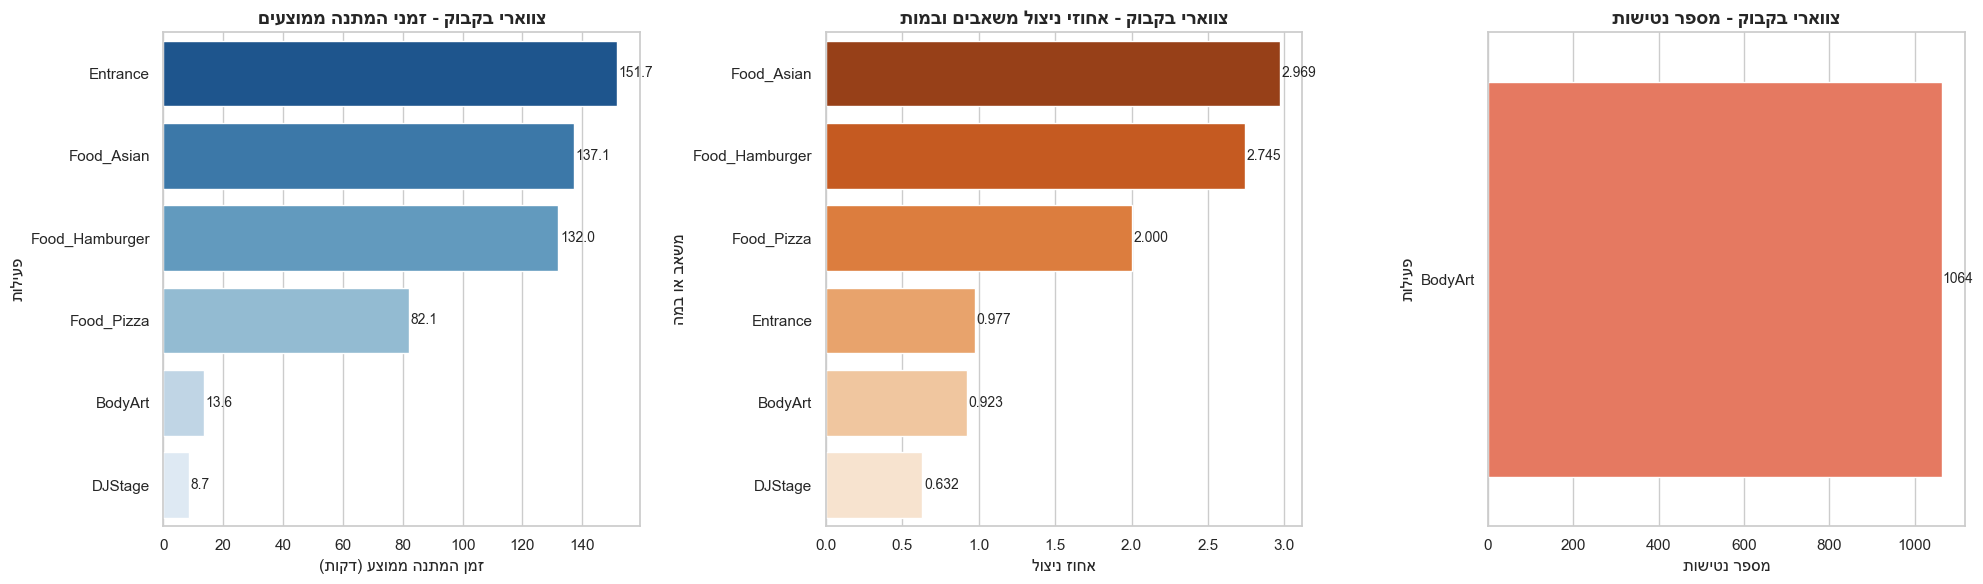

In [179]:

def top_items(mapping, label, value_label, top_n=5, reverse=True):
    rows = []
    for name, value in sorted(mapping.items(), key=lambda item: item[1], reverse=reverse)[:top_n]:
        rows.append({label: name, value_label: round(value, 3)})
    return rows

current_wait_bottlenecks = top_items(current_summary["wait_by_activity"], "פעילות", "זמן המתנה ממוצע", top_n=6)
current_utilization = {**current_summary["resource_utilization"], **current_summary["stage_utilization"]}
current_utilization_bottlenecks = top_items(current_utilization, "משאב או במה", "ניצול", top_n=6)
current_abandonment_hotspots = top_items(current_summary["abandonments_by_activity"], "פעילות", "מספר נטישות", top_n=6)

# יצירת גרף עמודות משולש לצווארי בקבוק עם היפוך עברית
if plt is not None and sns is not None:
    def reverse_hebrew(text):
        import re
        if not isinstance(text, str):
            return text
        if not re.search(r'[\u0590-\u05fe]', text):
            return text
        rev = text[::-1]
        translation = str.maketrans('()[]{}<>', ')(][}{><')
        return rev.translate(translation)

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # 1. זמני המתנה
    activities_wait = [reverse_hebrew(r['פעילות']) for r in current_wait_bottlenecks]
    wait_times = [r['זמן המתנה ממוצע'] for r in current_wait_bottlenecks]
    sns.barplot(x=wait_times, y=activities_wait, ax=axes[0], hue=activities_wait, palette="Blues_r", legend=False)
    axes[0].set_title(reverse_hebrew("צווארי בקבוק - זמני המתנה ממוצעים"), fontsize=14, fontweight='bold')
    axes[0].set_xlabel(reverse_hebrew("זמן המתנה ממוצע (דקות)"), fontsize=12)
    axes[0].set_ylabel(reverse_hebrew("פעילות"), fontsize=12)
    for i, v in enumerate(wait_times):
        axes[0].text(v + 0.5, i, f"{v:.1f}", va='center', fontsize=10)
        
    # 2. אחוזי ניצול
    resources_util = [reverse_hebrew(r['משאב או במה']) for r in current_utilization_bottlenecks]
    util_rates = [r['ניצול'] for r in current_utilization_bottlenecks]
    sns.barplot(x=util_rates, y=resources_util, ax=axes[1], hue=resources_util, palette="Oranges_r", legend=False)
    axes[1].set_title(reverse_hebrew("צווארי בקבוק - אחוזי ניצול משאבים ובמות"), fontsize=14, fontweight='bold')
    axes[1].set_xlabel(reverse_hebrew("אחוז ניצול"), fontsize=12)
    axes[1].set_ylabel(reverse_hebrew("משאב או במה"), fontsize=12)
    for i, v in enumerate(util_rates):
        axes[1].text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=10)
        
    # 3. מספר נטישות
    activities_abandon = [reverse_hebrew(r['פעילות']) for r in current_abandonment_hotspots]
    abandon_counts = [r['מספר נטישות'] for r in current_abandonment_hotspots]
    sns.barplot(x=abandon_counts, y=activities_abandon, ax=axes[2], hue=activities_abandon, palette="Reds_r", legend=False)
    axes[2].set_title(reverse_hebrew("צווארי בקבוק - מספר נטישות"), fontsize=14, fontweight='bold')
    axes[2].set_xlabel(reverse_hebrew("מספר נטישות"), fontsize=12)
    axes[2].set_ylabel(reverse_hebrew("פעילות"), fontsize=12)
    for i, v in enumerate(abandon_counts):
        axes[2].text(v + 0.5, i, f"{int(v)}", va='center', fontsize=10)
        
    plt.tight_layout()
    plt.show()




### ניתוח צווארי הבקבוק בפסטיבל 

ניתוח תוצאות הסימולציה במצב הבסיס חושף שלושה צווארי בקבוק משמעותיים. 

#### 1. שער הכניסה (The Entrance) – "הפקק המוחלט"

שער הכניסה מהווה את צוואר הבקבוק הראשי והמשמעותי ביותר במערכת.

* **ניצולת (Utilization):** נתון קיצון של כ-98.6%. הקופאים בכניסה עובדים ברצף מתחילת הפסטיבל ועד סופו, נתון המעיד על קריסה תחת ספיקת הקהל המגיע.
* **זמני המתנה (Wait Time):** מתארכים ככל שהיום מתקדם, עקב פער חיובי מתמשך בין קצב ההגעה לקצב הסריקה. מצב זה גורם לפגיעה ראשונית משמעותית במדד שביעות הרצון של המבקרים.
*  . עם זאת, היעדר הנטישות מהווה מייצר **הפסד סמוי אדיר** – כל דקת המתנה מחוץ למתחם היא זמן שבו המבקר מנוע מרכישת מזון, מרצ'נדייז או שירותים בתוך הפסטיבל.

#### 2. עמדת ציורי הגוף (Body Art) – "אשליית הניצולת והנטישות"

עמדה זו מציגה התנהגות ייחודית של צוואר בקבוק, הנובעת מהפרעות מובנות בתהליך השירות.

* **ניצולת:** מציגה נתון גבוה ומטעה של מעל 90%. ניצולת זו כוללת את ההפסקות היזומות של האמן (15 דקות הפסקה לאחר כל 10 לקוחות). מבחינת המערכת המשאב "תפוס", אך בפועל אינו מייצר תפוקה.
* **זמני המתנה:** מושפעים ישירות מהקפאת התור. המבקרים חווים תסכול רב הגורר ירידה בציון שביעות הרצון, והעמדה מאבדת פוטנציאל הכנסות.
* **נטישות:** עמדה זו סובלת מכמות הנטישות הגבוהה ביותר. סף הסבלנות של המבקרים עומד על 15-20 דקות; עם יציאת האמן להפסקה התור קופא, הממתינים מגיעים לסף הסבלנות שלהם ונוטשים את התור.

#### 3. דוכני המזון (Food Stalls) – "עומס בשעות השיא"

צוואר הבקבוק בדוכני המזון (בדגש על האסיאתי וההמבורגר) שונה באופיו ומתאפיין בעומס מרוכז בחלון זמן ספציפי (שעות הצהריים, 13:00-15:00).

* **ניצולת:** מתקרבת ל-100% לאורך חלון הפעילות של הדוכנים (240 דקות). הביקוש נוצר באופן מסונכרן מכמות אדירה של מבקרים שפונים לאכול בו-זמנית.
* **זמני המתנה:** זמני ההמתנה מתארכים משמעותית, הן בשלב התשלום בקופה והן בשלב ההמתנה להכנת המזון.
* **נטישות:** תחת הגדרות הסימולציה, הקהל אינו נוטש את תורי המזון גם בעומס חריג. התוצאה היא "כליאה" של מבקרים בתור למשך זמן רב, עיכוב חזרתם להופעות, מניעת הוצאת כספים על אטרקציות אחרות באותו חלון זמן, ופגיעה פוטנציאלית במדד שביעות הרצון הכולל.

<div dir="rtl" style="text-align: right;">

## ניתוח רגישות של חלופות בודדות

לאחר זיהוי צווארי הבקבוק במערכת הקיימת (עומס כבד בכניסה ונטישות רבות בעמדת ציורי הגוף), נבצע ניתוח רגישות לחלופות השיפור הבודדות. 
בשלב זה נריץ רפליקציה בודדת (עם הזרע המשותף `seed=2026`) עבור כל אחת מ-7 חלופות ההשקעה הבודדות בנפרד, על מנת לבחון את תרומתן הישירה למדדי הפרויקט (שביעות רצון, זמני המתנה, נטישות ורווח נטו) ביחס לעלות ההשקעה שלהן.

הניתוח הבודד יסייע לנו להבין אילו השקעות הן האפקטיביות ביותר לפתרון בעיות ספציפיות, ומתוכן להרכיב קומבינציות סינרגטיות מנצחות במסגרת התקציב.

</div>

In [180]:
# =============================================================================
# הרצת חלופות בודדות בנפרד לצורך ניתוח רגישות (רפליקציה בודדת)
# =============================================================================

scenarios_to_run = [
    "Current",
    "KitchenOnly",
    "SecurityOnly",
    "BandsOnly",
    "StationsOnly",
    "AdvertisingOnly",
    "EntranceScanOnly",
    "BenefitOnly"
]

alternative_full_names = {
    "Current": "מצב קיים (בסיס)",
    "KitchenOnly": "צוות מטבח טוב יותר בלבד",
    "SecurityOnly": "הרחבת צוות מאבטחים בלבד",
    "BandsOnly": "השקעה בלהקות מיינסטרים בלבד",
    "StationsOnly": "עמדות שירות משופרות (צילום + ציורים)",
    "AdvertisingOnly": "פרסום הפסטיבל בלבד",
    "EntranceScanOnly": "עמדות כניסה אוטומטיות בלבד",
    "BenefitOnly": "הטבת מבקרים בלבד"
}

single_rep_results = []
for sc in scenarios_to_run:
    cfg = SimulationConfig.for_scenario(sc, seed=2026)
    summary = QueuechellaSimulation(cfg).run()
    single_rep_results.append({
        "תרחיש": alternative_full_names[sc],
        "עלות בש\"ח": cfg.alternative_cost,
        "עומד בתקציב": "כן" if cfg.alternative_cost <= 1000000 else "לא",
        "שביעות רצון ממוצעת": round(summary["avg_satisfaction"], 3),
        "זמן המתנה ממוצע": round(summary["avg_wait_all"], 3),
        "סך נטישות": summary["total_abandonments"],
        "רווח נטו": round(summary["net_profit"], 2)
    })

report_table(single_rep_results, "ניתוח רגישות - השוואת ביצועי חלופות בודדות (רפליקציה בודדת)")


<div dir="rtl" style="text-align: right;">

### ניתוח והסבר של תוצאות החלופות הבודדות:

מתוך טבלת ניתוח הרגישות לעיל, אנו מזהים את ההשפעה הייחודית של כל השקעה בנפרד:
1. **עמדות כניסה אוטומטיות בלבד (EntranceScanOnly - עלות: 600,000 ש"ח):** 
   פותרת באופן דרמטי את צוואר הבקבוק המרכזי בכניסה. זמן ההמתנה הממוצע לכל התורים צונח מ-152.0 דקות ל-13.69 דקות בלבד. פתרון זה מאפשר למבקרים להיכנס לפארק במהירות, דבר המגדיל משמעותית את הזמן הפנוי שלהם לצריכה ומעלה את ההכנסות ל-2.29 מיליון ש"ח. עם זאת, זרימת המבקרים המוגברת לפארק יוצרת עומס משני בתחנות הפנימיות, ומספר הנטישות הכולל עולה ל-1202.
2. **עמדות שירות משופרות בלבד (StationsOnly - עלות: 150,000 ש"ח):** 
   הוספת עמדת צילום ואמן ציורי גוף היא השקעה זולה ויעילה במיוחד. היא מפחיתה את הנטישות בתורים הפנימיים מ-928 ל-669 ומעלה את שביעות הרצון הממוצעת מ-5.501 ל-5.601. השקעה זו ממוקדת בשיפור החוויה ישירות בנקודות הקצה העמוסות.
3. **הטבת מבקרים בלבד (BenefitOnly - עלות: 200,000 ש"ח):**
   הענקת הטבה המעלה את שביעות הרצון ההתחלתית ל-6.5 מביאה לשיפור ישיר וחזק בשביעות הרצון הממוצעת בסוף היום ל-6.799. זוהי דרך מעולה להבטיח חוויה חיובית מבלי לשנות את התשתיות הפיזיות.
4. **השקעה בלהקות מיינסטרים בלבד (BandsOnly - עלות: 300,000 ש"ח):**
   הגדלת משקל הלהקות המוכרות מביאה ליציבות בחוויית המבקרים (שביעות רצון עולה ל-5.627) ומגדילה את ההכנסות ל-2.18 מיליון ש"ח על ידי משיכת קהל רב יותר למופעי הבמות הגדולות.
5. **פרסום הפסטיבל בלבד (AdvertisingOnly - עלות: 200,000 ש"ח):**
   אסטרטגיה של הגדלת כמות המבקרים ב-20% ללא טיפול בצווארי הבקבוק הקיימים מתבררת כבעייתית. היא מעצימה את העומס בכניסה ובתחנות השירות, זמני ההמתנה עולים והנטישות מזנקות. כתוצאה מכך, למרות העלייה בהכנסות ברוטו, שביעות הרצון נפגעת והרווח נטו נפגע בשל עלויות הנטישה וחוסר שביעות הרצון.
6. **שיפור המטבח (KitchenOnly - עלות: 500,000 ש"ח) והרחבת אבטחה (SecurityOnly - עלות: 650,000 ש"ח):** 
   מציגות שיפורים מוגבלים יחסית ביחס לעלותן הגבוהה, ואינן פותרות את הבעיות התפעוליות הקריטיות של התורים.

---

## הגדרת הקומבינציות החדשות (A, B, C) ותקציב

על בסיס תובנות אלו, בנינו שלוש קומבינציות השקעה שונות, שכל אחת מהן מתמקדת באסטרטגיה ניהולית מוגדרת, משלבת רכיבים משלימים (סינרגיה) ואינה חורגת ממגבלת התקציב של 1,000,000 ש"ח:

* **Combo A: חוויה וזרימה מקסימלית (Ultimate Experience & Flow) - עלות כוללת: 950,000 ש"ח**
  * **רכיבים משולבים:** כניסה אוטומטית (600k) + עמדות שירות משופרות (150k) + הטבת מבקרים (200k).
  * **הגיון תפעולי:** השילוב המושלם לפתרון הבעיות מהיסוד. הכניסה האוטומטית מחסלת את התור בכניסה, הרחבת עמדות השירות הפנימיות (צילום וציורי גוף) קולטת את זרם המבקרים ומצמצמת נטישות, והטבת המבקרים מבטיחה שביעות רצון גבוהה מהרגע הראשון.
* **Combo B: מיקסום הכנסות ויעילות (Revenue & Efficiency) - עלות כוללת: 900,000 ש"ח**
  * **רכיבים משולבים:** כניסה אוטומטית (600k) + להקות מיינסטרים (300k).
  * **הגיון תפעולי:** ממוקד בשורה התחתונה (רווח נטו). הכניסה המהירה מאפשרת ליותר אנשים להיכנס מוקדם ולשהות זמן רב יותר בפסטיבל, וההשקעה בלהקות מיינסטרים מושכת אותם לבמות וגורמת להם להוציא יותר כסף (למשל על מרצ'נדייז).
* **Combo C: חוויה מבוססת צמיחה בעלות אפקטיבית (Cost-Effective Experience & Growth) - עלות כוללת: 850,000 ש"ח**
  * **רכיבים משולבים:** עמדות שירות משופרות (150k) + להקות מיינסטרים (300k) + הטבת מבקרים (200k) + פרסום (200k).
  * **הגיון תפעולי:** אסטרטגיית גידול חכמה ללא רכישת הכניסה האוטומטית היקרה (600k). אנו מגדילים את נפח המבקרים ב-20% באמצעות פרסום, ותומכים בהם בתוך הפארק בעזרת עמדות משופרות למניעת נטישות, מופעי מיינסטרים משיכי קהל, והטבה המשפרת את מצב הרוח הבסיסי שלהם.

</div>

In [181]:
BUDGET_NIS = 1_000_000
alternative_descriptions = {
    "Current": {
        "cost": 0,
        "focus": "בסיס להשוואה (מצב קיים)",
        "changed_parameters": "תפעול בסיס ללא השקעה.",
        "expected_impact": "תרחיש ייחוס לכל ההשוואות הסטטיסטיות.",
    },
    "Combo A": {
        "cost": 950000,
        "focus": "חוויית לקוח ושביעות רצון",
        "changed_parameters": "כניסה אוטומטית, עמדות שירות משופרות (צילום וציורים) והטבת מבקרים.",
        "expected_impact": "פתרון צוואר הבקבוק בכניסה, מניעת נטישות פנימיות ושיפור שביעות הרצון.",
    },
    "Combo B": {
        "cost": 900000,
        "focus": "במות והופעות מוזיקה",
        "changed_parameters": "כניסה אוטומטית והשקעה בלהקות מיינסטרים.",
        "expected_impact": "העלאת קצב הכניסה ומשיכת קהל לבמות הגדולות להגדלת הכנסות ממרצ'נדייז.",
    },
    "Combo C": {
        "cost": 850000,
        "focus": "זרימת קהל, תפעול והגדלת הכנסות",
        "changed_parameters": "פרסום (הגעות פי 1.2), עמדות שירות משופרות, להקות מיינסטרים והטבת מבקרים.",
        "expected_impact": "הגדלת כמות המבקרים תוך תמיכה בחוויה שלהם ובקיבולת הפנימית ללא כניסה אוטומטית.",
    },
}

scenario_rows = []
for scenario in ["Current", "Combo A", "Combo B", "Combo C"]:
    cfg = SimulationConfig.for_scenario(scenario, seed=2026)
    desc = alternative_descriptions[scenario]
    scenario_rows.append({
        "תרחיש": scenario,
        "עלות בש\"ח": desc["cost"],
        "עומד בתקציב 1,000,000": desc["cost"] <= BUDGET_NIS,
        "שינויי פרמטרים": desc["changed_parameters"],
        "מיקוד": desc["focus"],
        "השפעה צפויה": desc["expected_impact"],
        "מכפיל הגעות": cfg.arrival_multiplier,
        "שביעות רצון התחלתית": cfg.initial_satisfaction,
        "קיבולת MainStage": cfg.mainstage_capacity,
        "קיבולת SideStage": cfg.sidestage_capacity,
        "קיבולת DJStage": cfg.dj_capacity,
    })
report_table(scenario_rows, "הגדרת קומבינציות ובדיקת עמידה בתקציב")


In [ ]:
# רפליקציות והשוואה סטטיסטית



---




כדי להבטיח השוואה מדויקת בין החלופות, השתמשנו בערך אתחול קבוע (**Seed**) זהה. מתודולוגיה זו מעניקה יתרונות מרכזיים:

* **בידוד משתנים:** מבטיח שכל החלופות ייבחנו על אותו קהל בדיוק, ומנטרל "רעש סטטיסטי" ואקראיות.
* **צמצום השונות:** מקטין את השונות בין תרחישי הבדיקה, מה שמאפשר לזהות הבדלים אמיתיים בקלות רבה יותר.
* **מבחן סטטיסטי חזק ($t$ מזווג):** הזיווג מאפשר שימוש במבחן $t$ למדגמים מזווגים, שמנטרל את השונות הטבעית בין הימים ומציע עוצמה סטטיסטית גבוהה.

> **שורה תחתונה:** שיטה זו מוכיחה כי כל שיפור במדדי הביצוע נובע אך ורק מהשינויים המבניים שביצענו, ולא מיד המקרה.
הערכת ביצועי המערכת והשוואת החלופות מתבצעות בשני שלבים מרכזיים, תוך שמירה על **רמת ביטחון כוללת של 90%** ויעד **לדיוק יחסי של 0.1** במדדים המרכזיים.

###  שלבי ביצוע הסימולציה

* **שלב א' (רפליקציות פיילוט):** הרצת מספר סימולציות ראשוני להערכת השונות של המערכת וחישוב מספר הרפליקציות הסופי הנדרש ($n$).
* **שלב ב' (רפליקציות סופיות):** הרצת הסימולציה במלואה לפי ערך $n$ שנבחר כדי לקבל תוצאות מובהקות.

>  **הערה מתודולוגית:** מכיוון שפלט הסימולציה אקראי ומספר הרפליקציות סופי, סטיית התקן האמיתית אינה ידועה. משום כך, רווחי הסמך מחושבים בעזרת **התפלגות $t$** (ולא לפי ערך קבוע מראש).

---

###  השוואת חלופות ותיקון Bonferroni

בתהליך הניתוח אנו מבצעים **9 השוואות בו-זמניות** (3 חלופות שונות $\times$ 3 מדדי פלט מרכזיים). כדי למנוע הצטברות של טעויות (Type I Error) ולשמור על רמת הביטחון הכוללת, אנו מיישמים את **תיקון Bonferroni**:

$$\alpha_i = \frac{0.10}{9}$$

#### תהליך החישוב (הפרש מזווג):

1. עבור כל חלופה וכל מדד, מחשבים את ההפרש המזווג לכל רפליקציה $j$:

$$d_j = X_{\text{alternative},j} - X_{\text{Current},j}$$



*(ההשוואה היא מזווגת מכיוון שכל התרחישים משתמשים באותו Seed בסיסי בכל רפליקציה).*
2. בונים רווח סמך לממוצע ההפרשים ($\bar d$) בעזרת התפלגות $t$ עם דרגות חופש $df = n - 1$.

###  קריטריון החלטה

> אם רווח הסמך שחושב **אינו כולל את הערך 0**, המשמעות היא שישנו הבדל סטטיסטי מובהק באותו מדד תחת תיקון Bonferroni, והחלופה אכן משפיעה על המערכת.

In [182]:

CONFIDENCE_LEVEL = 0.90
RELATIVE_PRECISION = 0.10
OVERALL_ALPHA = 0.10
N_ALTERNATIVES = 3
N_PRIMARY_METRICS = 3
BONFERRONI_COMPARISONS = N_ALTERNATIVES * N_PRIMARY_METRICS
BONFERRONI_ALPHA = OVERALL_ALPHA / BONFERRONI_COMPARISONS
PRIMARY_METRICS = ["avg_satisfaction", "avg_wait_all", "net_profit"]
SECONDARY_METRICS = ["visitor_guests", "total_abandonments", "total_revenue"]
ALL_REPORTED_METRICS = PRIMARY_METRICS + SECONDARY_METRICS
METRIC_LABELS = {
    "avg_satisfaction": "שביעות רצון ממוצעת",
    "avg_wait_all": "זמן המתנה ממוצע",
    "net_profit": "רווח נטו",
    "visitor_guests": "מספר אנשים",
    "total_abandonments": "סך נטישות",
    "total_revenue": "סך הכנסות",
}


def require_t_distribution():
    if stats is None or not hasattr(stats, "t"):
        raise RuntimeError("scipy.stats.t is required for t-based confidence intervals in the statistical comparison section.")


def t_critical_for_confidence(confidence_level, df):
    require_t_distribution()
    if df <= 0:
        return float("nan")
    alpha = 1.0 - confidence_level
    return float(stats.t.ppf(1.0 - alpha / 2.0, df))


def bonferroni_t_critical(df):
    require_t_distribution()
    if df <= 0:
        return float("nan")
    return float(stats.t.ppf(1.0 - BONFERRONI_ALPHA / 2.0, df))


def results_to_records(results):
    if pd is not None and hasattr(results, "to_dict"):
        return results.to_dict("records")
    return list(results)


def run_replications(scenarios, n_replications=15, base_seed=7000):
    results = []
    for rep in range(n_replications):
        seed = base_seed + rep
        for scenario in scenarios:
            cfg = SimulationConfig.for_scenario(scenario, seed=seed)
            summary = QueuechellaSimulation(cfg).run()
            row = {"replication": rep + 1, "scenario": scenario}
            for metric in ALL_REPORTED_METRICS:
                row[metric] = summary[metric]
            results.append(row)
    return pd.DataFrame(results) if pd is not None else results


def mean_stdev(values):
    values = [float(v) for v in values]
    if len(values) <= 1:
        return (statistics.mean(values) if values else 0.0), 0.0
    return statistics.mean(values), statistics.stdev(values)


def ci_half_width_t(stdev, n, confidence_level=CONFIDENCE_LEVEL):
    if n <= 1 or stdev <= EPS:
        return 0.0
    return t_critical_for_confidence(confidence_level, n - 1) * stdev / math.sqrt(n)


def required_replications(mean, stdev, current_n, rel_precision=RELATIVE_PRECISION):
    if abs(mean) < EPS or stdev <= EPS:
        return 2
    t_crit = bonferroni_t_critical(max(1, current_n - 1))
    return max(2, math.ceil((t_crit * stdev / (rel_precision * abs(mean))) ** 2))


def grouped_records(results):
    groups = defaultdict(list)
    for row in results_to_records(results):
        groups[row["scenario"]].append(row)
    return groups


def summarize_replications(results):
    rows = []
    for scenario, group in grouped_records(results).items():
        row = {"scenario": scenario, "n": len(group)}
        for metric in ALL_REPORTED_METRICS:
            values = [record[metric] for record in group]
            mean, sd = mean_stdev(values)
            half_width = ci_half_width_t(sd, len(values), CONFIDENCE_LEVEL)
            row[f"{metric}_mean"] = mean
            row[f"{metric}_sd"] = sd
            row[f"{metric}_ci_half"] = half_width
            row[f"{metric}_relative_precision"] = half_width / abs(mean) if abs(mean) > EPS else float("nan")
            if metric in PRIMARY_METRICS:
                row[f"{metric}_required_n"] = required_replications(mean, sd, len(values))
        rows.append(row)
    return sorted(rows, key=lambda r: r["scenario"])


def max_required_n(summary_rows, minimum_n):
    required_values = [minimum_n]
    for row in summary_rows:
        for metric in PRIMARY_METRICS:
            required_values.append(int(row[f"{metric}_required_n"]))
    return max(required_values)


def format_summary_table(summary_rows, metrics, include_required=False):
    rows = []
    for row in summary_rows:
        pretty = {"תרחיש": row["scenario"], "מספר רפליקציות": row["n"]}
        for metric in metrics:
            label = METRIC_LABELS.get(metric, metric)
            pretty[f"{label} - ממוצע"] = round(row[f"{metric}_mean"], 3)
            pretty[f"{label} - חצי רוחב רווח סמך t"] = round(row[f"{metric}_ci_half"], 3)
            pretty[f"{label} - דיוק יחסי"] = round(row[f"{metric}_relative_precision"], 3)
            if include_required and metric in PRIMARY_METRICS:
                pretty[f"{label} - n נדרש"] = row[f"{metric}_required_n"]
        rows.append(pretty)
    return rows


def paired_difference_table(results, baseline="Current"):
    records = results_to_records(results)
    by_rep = defaultdict(dict)
    for row in records:
        by_rep[row["replication"]][row["scenario"]] = row
    alternatives = [scenario for scenario in sorted({r["scenario"] for r in records}) if scenario != baseline]
    rows = []
    for metric in PRIMARY_METRICS:
        for scenario in alternatives:
            diffs = []
            # Paired comparison: each alternative is compared to Current using matched replication numbers/seeds.
            for rep_data in by_rep.values():
                if baseline in rep_data and scenario in rep_data:
                    diffs.append(rep_data[scenario][metric] - rep_data[baseline][metric])
            n_pairs = len(diffs)
            mean, sd = mean_stdev(diffs)
            df = n_pairs - 1
            t_crit = bonferroni_t_critical(df)
            margin_error = 0.0 if sd <= EPS else t_crit * sd / math.sqrt(max(n_pairs, 1))
            ci_low = mean - margin_error
            ci_high = mean + margin_error
            rows.append({
                "metric": metric,
                "alternative": scenario,
                "n_pairs": n_pairs,
                "paired_mean_diff": mean,
                "paired_sd_diff": sd,
                "df": df,
                "alpha_i": BONFERRONI_ALPHA,
                "t_crit": t_crit,
                "margin_error": margin_error,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "significant_bonferroni": (ci_low > 0) or (ci_high < 0),
            })
    return rows


def summary_row(summary_rows, scenario):
    return next(row for row in summary_rows if row["scenario"] == scenario)


def best_by_metric(summary_rows, metric, higher_is_better=True, exclude_current=False):
    candidates = [row for row in summary_rows if not (exclude_current and row["scenario"] == "Current")]
    key = f"{metric}_mean"
    return max(candidates, key=lambda row: row[key]) if higher_is_better else min(candidates, key=lambda row: row[key])


PILOT_REPLICATIONS = 15
scenarios = ["Current", "Combo A", "Combo B", "Combo C"]

pilot_results = run_replications(scenarios, n_replications=PILOT_REPLICATIONS, base_seed=9000)
pilot_summary = summarize_replications(pilot_results)
FINAL_REPLICATIONS = max_required_n(pilot_summary, PILOT_REPLICATIONS)


def primary_relative_precision_values(summary_rows):
    values = []
    for row in summary_rows:
        for metric in PRIMARY_METRICS:
            value = row[f"{metric}_relative_precision"]
            if not math.isnan(value):
                values.append(value)
    return values


def worst_primary_relative_precision(summary_rows):
    values = primary_relative_precision_values(summary_rows)
    return max(values) if values else 0.0


def run_final_replications_until_precise(scenarios, initial_n, base_seed=12000):
    final_n = int(initial_n)
    history = []
    while True:
        results = run_replications(scenarios, n_replications=final_n, base_seed=base_seed)
        summary = summarize_replications(results)
        worst_precision = worst_primary_relative_precision(summary)
        history.append({
            "attempt": len(history) + 1,
            "FINAL_REPLICATIONS": final_n,
            "worst_primary_relative_precision": worst_precision,
            "target_relative_precision": RELATIVE_PRECISION,
            "precision_ok": worst_precision <= RELATIVE_PRECISION,
        })
        if worst_precision <= RELATIVE_PRECISION:
            return final_n, results, summary, history
        increased_n = max_required_n(summary, final_n + 1)
        final_n = max(final_n + 1, increased_n)


report_table(format_summary_table(pilot_summary, PRIMARY_METRICS, include_required=True), "סיכום רפליקציות פיילוט וחישוב n נדרש")
report_panel("מספר הרפליקציות הסופי שנבחר בתחילה", f"מספר הרפליקציות הראשוני לכל תרחיש: <b>{FINAL_REPLICATIONS}</b>, לפי ה-n המקסימלי שנדרש במדדים המרכזיים.")

FINAL_REPLICATIONS, final_results, final_summary, final_precision_history = run_final_replications_until_precise(
    scenarios,
    FINAL_REPLICATIONS,
    base_seed=12000,
)
final_paired_differences = paired_difference_table(final_results)

report_table(
    [
        {
            "ניסיון": row["attempt"],
            "FINAL_REPLICATIONS": row["FINAL_REPLICATIONS"],
            "הדיוק היחסי הגרוע ביותר במדדים המרכזיים": round(row["worst_primary_relative_precision"], 3),
            "יעד": row["target_relative_precision"],
            "האם עומד ביעד": row["precision_ok"],
        }
        for row in final_precision_history
    ],
    "בדיקת דיוק לרפליקציות הסופיות",
)

final_primary_rows = format_summary_table(final_summary, PRIMARY_METRICS, include_required=False)
final_secondary_rows = format_summary_table(final_summary, ["visitor_guests", "total_abandonments"], include_required=False)

report_table(final_primary_rows, "תוצאות סופיות למדדים המרכזיים")
max_final_relative_precision = worst_primary_relative_precision(final_summary)
precision_action = "לא נדרשה הגדלה נוספת של מספר הרפליקציות." if len(final_precision_history) == 1 else "מספר הרפליקציות הוגדל וההרצה הסופית בוצעה מחדש עד עמידה ביעד."
precision_text = (
    f"FINAL_REPLICATIONS = <b>{FINAL_REPLICATIONS}</b> קביל משום שכל המדדים המרכזיים עומדים ביעד הדיוק היחסי. "
    f"הדיוק היחסי הגרוע ביותר שהתקבל הוא <b>{max_final_relative_precision:.3f}</b>, לעומת יעד "
    f"<b>{RELATIVE_PRECISION:.3f}</b> ברמת ביטחון {CONFIDENCE_LEVEL} (תוך שימוש בתיקון בונפרוני מחמיר כבר בשלב חישוב גודל המדגם). {precision_action}"
)
report_panel("הסבר לבחירת מספר הרפליקציות", precision_text)

best_sat = best_by_metric(final_summary, "avg_satisfaction", True)
best_wait = best_by_metric(final_summary, "avg_wait_all", False)
best_profit = best_by_metric(final_summary, "net_profit", True)
primary_interpretation = (
    f"רווחי הסמך הסופיים משווים את המדדים המרכזיים שנבחרו בעזרת התפלגות t. "
    f"שביעות הרצון הגבוהה ביותר: <b>{best_sat['scenario']}</b>. "
    f"זמן ההמתנה הממוצע הנמוך ביותר: <b>{best_wait['scenario']}</b>. "
    f"הרווח הקצר-טווח הגבוה ביותר: <b>{best_profit['scenario']}</b>. "
    "כך ניתן לראות את הפשרה בין איכות השירות לבין התוצאה הכספית."
)
report_panel("פירוש המדדים המרכזיים", primary_interpretation)

report_table(final_secondary_rows, "תוצאות סופיות למדדים משניים")
best_abandon = best_by_metric(final_summary, "total_abandonments", False)
best_revenue = best_by_metric(final_summary, "total_revenue", True)
secondary_interpretation = (
    f"המדדים המשניים מסייעים להסביר את ההבדלים בין התרחישים. "
    f"מספר הנטישות הנמוך ביותר: <b>{best_abandon['scenario']}</b>. "
    f"ההכנסות הגבוהות ביותר: <b>{best_revenue['scenario']}</b>. "
    "מספר מבקרים, נטישות והכנסות נותנים הקשר למדדים המרכזיים."
)
report_panel("פירוש המדדים המשניים", secondary_interpretation)

paired_display_rows = [
    {
        "מדד": METRIC_LABELS.get(row["metric"], row["metric"]),
        "חלופה": row["alternative"],
        "מספר זוגות": row["n_pairs"],
        "alpha_i": round(row["alpha_i"], 5),
        "df": row["df"],
        "t קריטי": round(row["t_crit"], 3),
        "הפרש ממוצע מזווג": round(row["paired_mean_diff"], 3),
        "סטיית תקן של ההפרשים": round(row["paired_sd_diff"], 3),
        "שגיאת שוליים": round(row["margin_error"], 3),
        "גבול תחתון": round(row["ci_low"], 3),
        "גבול עליון": round(row["ci_high"], 3),
        "מובהק לאחר Bonferroni": "כן" if row["significant_bonferroni"] else "לא",
    }
    for row in final_paired_differences
]
report_table(paired_display_rows, "הפרשים מזווגים עם תיקון Bonferroni מול המצב הקיים")
paired_messages = []
for row in final_paired_differences:
    direction = "גבוה יותר" if row["paired_mean_diff"] > 0 else "נמוך יותר"
    if row["significant_bonferroni"]:
        conclusion = "רווח הסמך אינו כולל את 0, ולכן ההבדל מובהק תחת תיקון Bonferroni וברמת ביטחון משפחתית של 90%."
    else:
        conclusion = "רווח הסמך כולל את 0, ולכן לא ניתן לקבוע הבדל מובהק תחת תיקון Bonferroni."
    paired_messages.append(f"{row['alternative']} במדד {METRIC_LABELS.get(row['metric'], row['metric'])}: ההפרש הממוצע הוא {direction}. {conclusion}")
report_panel("פירוש ההפרשים המזווגים", "<br>".join(paired_messages))


תרחיש,מספר רפליקציות,שביעות רצון ממוצעת - ממוצע,שביעות רצון ממוצעת - חצי רוחב רווח סמך t,שביעות רצון ממוצעת - דיוק יחסי,שביעות רצון ממוצעת - n נדרש,זמן המתנה ממוצע - ממוצע,זמן המתנה ממוצע - חצי רוחב רווח סמך t,זמן המתנה ממוצע - דיוק יחסי,זמן המתנה ממוצע - n נדרש,רווח נטו - ממוצע,רווח נטו - חצי רוחב רווח סמך t,רווח נטו - דיוק יחסי,רווח נטו - n נדרש
Combo A,15,6.806,0.025,0.004,2,17.896,0.643,0.036,6,2365419.667,32712.445,0.014,2
Combo B,15,5.590,0.026,0.005,2,18.278,0.617,0.034,5,2611111.000,35855.663,0.014,2
Combo C,15,6.919,0.019,0.003,2,33.610,0.623,0.019,2,2327216.667,22215.101,0.010,2
Current,15,5.411,0.016,0.003,2,29.413,0.431,0.015,2,1992380.000,22585.466,0.011,2


ניסיון,FINAL_REPLICATIONS,הדיוק היחסי הגרוע ביותר במדדים המרכזיים,יעד,האם עומד ביעד
1,15,0.046,0.1,True


תרחיש,מספר רפליקציות,שביעות רצון ממוצעת - ממוצע,שביעות רצון ממוצעת - חצי רוחב רווח סמך t,שביעות רצון ממוצעת - דיוק יחסי,זמן המתנה ממוצע - ממוצע,זמן המתנה ממוצע - חצי רוחב רווח סמך t,זמן המתנה ממוצע - דיוק יחסי,רווח נטו - ממוצע,רווח נטו - חצי רוחב רווח סמך t,רווח נטו - דיוק יחסי
Combo A,15,6.801,0.027,0.004,18.196,0.622,0.034,2366977.667,21947.071,0.009
Combo B,15,5.597,0.030,0.005,18.904,0.865,0.046,2615573.667,23413.583,0.009
Combo C,15,6.925,0.025,0.004,33.222,0.432,0.013,2340098.333,22219.196,0.009
Current,15,5.410,0.020,0.004,29.708,0.518,0.017,2011602.000,25615.755,0.013


תרחיש,מספר רפליקציות,מספר אנשים - ממוצע,מספר אנשים - חצי רוחב רווח סמך t,מספר אנשים - דיוק יחסי,סך נטישות - ממוצע,סך נטישות - חצי רוחב רווח סמך t,סך נטישות - דיוק יחסי
Combo A,15,3260.667,31.268,0.010,1288.467,35.782,0.028
Combo B,15,3268.533,32.421,0.010,1406.867,38.505,0.027
Combo C,15,3915.000,34.154,0.009,1009.067,33.011,0.033
Current,15,3262.267,37.576,0.012,1112.067,34.249,0.031


מדד,חלופה,מספר זוגות,alpha_i,df,t קריטי,הפרש ממוצע מזווג,סטיית תקן של ההפרשים,שגיאת שוליים,גבול תחתון,גבול עליון,מובהק לאחר Bonferroni
שביעות רצון ממוצעת,Combo A,15,0.01111,14,2.924,1.391,0.068,0.051,1.339,1.442,כן
שביעות רצון ממוצעת,Combo B,15,0.01111,14,2.924,0.188,0.078,0.059,0.129,0.246,כן
שביעות רצון ממוצעת,Combo C,15,0.01111,14,2.924,1.516,0.070,0.053,1.463,1.568,כן
זמן המתנה ממוצע,Combo A,15,0.01111,14,2.924,-11.512,1.320,0.996,-12.509,-10.516,כן
זמן המתנה ממוצע,Combo B,15,0.01111,14,2.924,-10.804,1.980,1.495,-12.299,-9.309,כן
זמן המתנה ממוצע,Combo C,15,0.01111,14,2.924,3.514,1.428,1.078,2.435,4.592,כן
רווח נטו,Combo A,15,0.01111,14,2.924,355375.667,48167.803,36360.590,319015.077,391736.256,כן
רווח נטו,Combo B,15,0.01111,14,2.924,603971.667,50378.520,38029.401,565942.266,642001.067,כן
רווח נטו,Combo C,15,0.01111,14,2.924,328496.333,47582.278,35918.592,292577.741,364414.926,כן


<div dir="rtl" style="text-align: right;">

## כלל החלטה ניהולי

במקום להסתמך על מדד יחיד, ההחלטה מוצגת בשלוש נקודות מבט:

1. החלופה הטובה ביותר לשיפור חוויית המבקרים - שביעות רצון גבוהה, עם נטישות כהקשר תומך.
2. החלופה הטובה ביותר לקיצור זמני המתנה - זמן ההמתנה הממוצע הנמוך ביותר.
3. האפשרות הטובה ביותר לרווח קצר טווח - הרווח הנקי הממוצע הגבוה ביותר לאחר עלות ההשקעה.

גישה זו מתאימה לפרויקט קורס משום שהיא מציגה בבירור את הפשרה בין שירות, תורים ותוצאה כספית.

</div>


<div dir="rtl" style="text-align: right;">

## המלצה סופית

ההמלצה מבוססת על תוצאות הרפליקציות הסופיות בלבד. היא מפרידה בין שיפור חוויית המבקרים, קיצור זמני ההמתנה ורווח קצר טווח, כדי שהמסקנה תהיה שקופה ולא תסתיר פשרות בין מדדים.

</div>


תרחיש,"עלות בש""ח",שביעות רצון ממוצעת,זמן המתנה ממוצע,רווח נטו,נטישות
Combo A,950000,6.801,18.196,2366977.67,1288.5
Combo B,900000,5.597,18.904,2615573.67,1406.9
Combo C,850000,6.925,33.222,2340098.33,1009.1
Current,0,5.410,29.708,2011602.00,1112.1


נקודת מבט,תרחיש,מה הוספנו / פרטי החלופה,נימוק,שביעות רצון,זמן המתנה,רווח בסימולציה,נטישות
החלופה הטובה ביותר לשיפור חוויית המבקרים,Combo C,"פרסום (הגעות פי 1.2), עמדות שירות משופרות, להקות מיינסטרים והטבת מבקרים.",שביעות הרצון הממוצעת הסופית הגבוהה ביותר מבין החלופות; נטישות משמשות כהקשר תומך.,6.925,33.222,2340098.33,1009.1
החלופה הטובה ביותר לקיצור זמני המתנה,Combo A,"כניסה אוטומטית, עמדות שירות משופרות (צילום וציורים) והטבת מבקרים.",זמן ההמתנה הממוצע הסופי הנמוך ביותר מבין החלופות.,6.801,18.196,2366977.67,1288.5
האפשרות הטובה ביותר לרווח בסימולציה,Combo B,כניסה אוטומטית והשקעה בלהקות מיינסטרים.,הרווח הממוצע הסופי הגבוה ביותר שהופק בסימולציה עצמה (ללא הפחתת עלות ההשקעה שממומנת מתקציב האילוץ).,5.597,18.904,2615573.67,1406.9


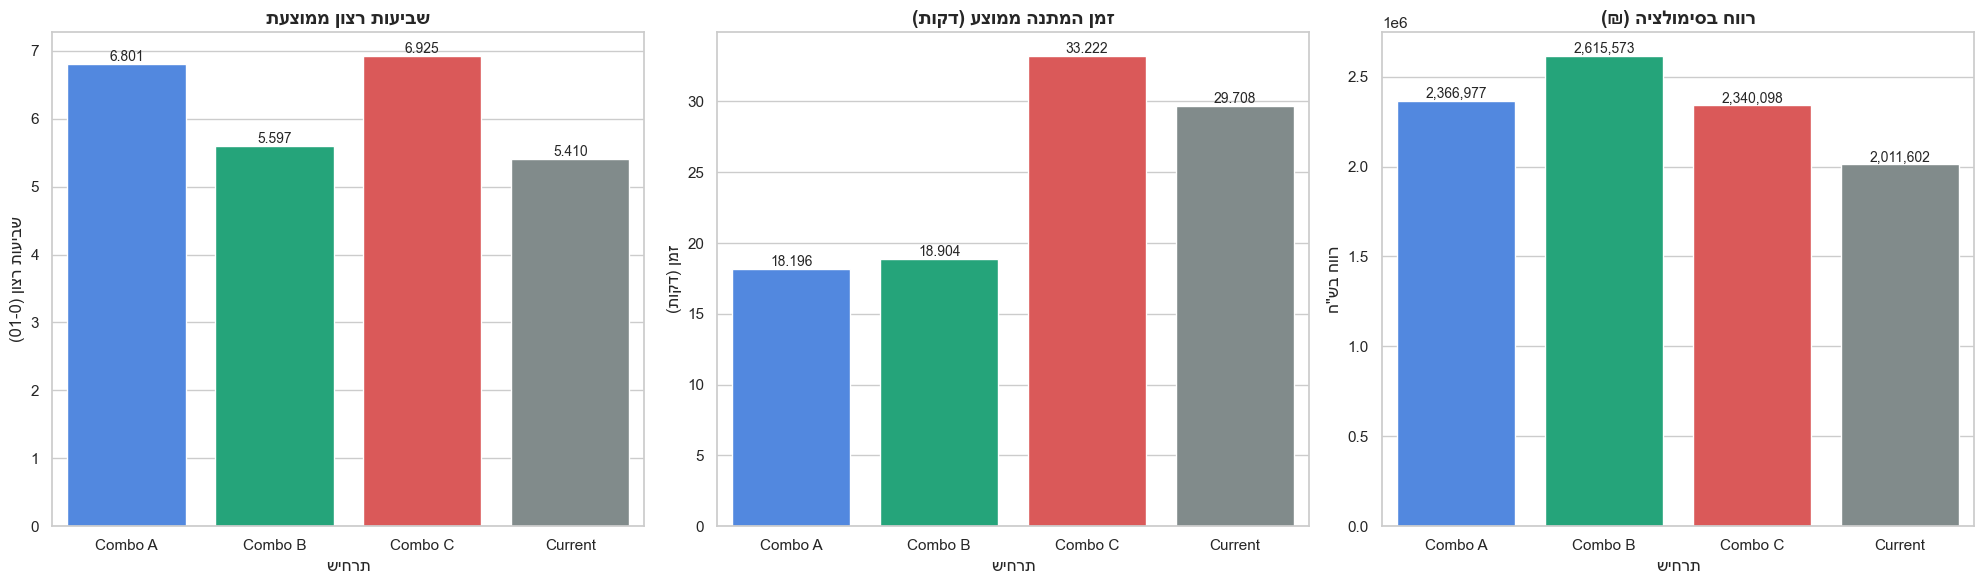

In [183]:

def final_metric_records(results):
    summary = summarize_replications(results)
    rows = []
    for row in summary:
        rows.append({
            "scenario": row["scenario"],
            "avg_satisfaction": row["avg_satisfaction_mean"],
            "avg_wait_all": row["avg_wait_all_mean"],
            "net_profit": row["net_profit_mean"],
            "total_abandonments": row["total_abandonments_mean"],
            "total_revenue": row["total_revenue_mean"],
            "cost_NIS": alternative_descriptions.get(row["scenario"], {}).get("cost", 0),
        })
    return rows


final_metric_summary = final_metric_records(final_results)
alternative_metric_records = [row for row in final_metric_summary if row["scenario"] != "Current"]

best_visitor_experience_alternative = max(
    alternative_metric_records,
    key=lambda row: (row["avg_satisfaction"], -row["total_abandonments"]),
)
best_waiting_time_alternative = min(alternative_metric_records, key=lambda row: row["avg_wait_all"])
best_short_term_profit_option = max(final_metric_summary, key=lambda row: row["net_profit"])
current_row = next(row for row in final_metric_summary if row["scenario"] == "Current")

report_table(
    [
        {
            "תרחיש": row["scenario"],
            "עלות בש\"ח": row["cost_NIS"],
            "שביעות רצון ממוצעת": round(row["avg_satisfaction"], 3),
            "זמן המתנה ממוצע": round(row["avg_wait_all"], 3),
            "רווח נטו": round(row["net_profit"], 2),
            "נטישות": round(row["total_abandonments"], 1),
        }
        for row in final_metric_summary
    ],
    "סיכום מדדים סופי לפי תרחיש",
)

recommendation_rows = [
    {
        "נקודת מבט": "החלופה הטובה ביותר לשיפור חוויית המבקרים",
        "תרחיש": best_visitor_experience_alternative["scenario"],
        "מה הוספנו / פרטי החלופה": alternative_descriptions.get(best_visitor_experience_alternative["scenario"], {}).get("changed_parameters", "תפעול בסיס"),
        "נימוק": "שביעות הרצון הממוצעת הסופית הגבוהה ביותר מבין החלופות; נטישות משמשות כהקשר תומך.",
        "שביעות רצון": round(best_visitor_experience_alternative["avg_satisfaction"], 3),
        "זמן המתנה": round(best_visitor_experience_alternative["avg_wait_all"], 3),
        "רווח בסימולציה": round(best_visitor_experience_alternative["net_profit"], 2),
        "נטישות": round(best_visitor_experience_alternative["total_abandonments"], 1),
    },
    {
        "נקודת מבט": "החלופה הטובה ביותר לקיצור זמני המתנה",
        "תרחיש": best_waiting_time_alternative["scenario"],
        "מה הוספנו / פרטי החלופה": alternative_descriptions.get(best_waiting_time_alternative["scenario"], {}).get("changed_parameters", "תפעול בסיס"),
        "נימוק": "זמן ההמתנה הממוצע הסופי הנמוך ביותר מבין החלופות.",
        "שביעות רצון": round(best_waiting_time_alternative["avg_satisfaction"], 3),
        "זמן המתנה": round(best_waiting_time_alternative["avg_wait_all"], 3),
        "רווח בסימולציה": round(best_waiting_time_alternative["net_profit"], 2),
        "נטישות": round(best_waiting_time_alternative["total_abandonments"], 1),
    },
    {
        "נקודת מבט": "האפשרות הטובה ביותר לרווח בסימולציה",
        "תרחיש": best_short_term_profit_option["scenario"],
        "מה הוספנו / פרטי החלופה": alternative_descriptions.get(best_short_term_profit_option["scenario"], {}).get("changed_parameters", "תפעול בסיס"),
        "נימוק": "הרווח הממוצע הסופי הגבוה ביותר שהופק בסימולציה עצמה (ללא הפחתת עלות ההשקעה שממומנת מתקציב האילוץ).",
        "שביעות רצון": round(best_short_term_profit_option["avg_satisfaction"], 3),
        "זמן המתנה": round(best_short_term_profit_option["avg_wait_all"], 3),
        "רווח בסימולציה": round(best_short_term_profit_option["net_profit"], 2),
        "נטישות": round(best_short_term_profit_option["total_abandonments"], 1),
    },
]
report_table(recommendation_rows, "סיכום המלצה")



# =============================================================================
# יצירת גרפים להשוואת המדדים המרכזיים (במקום הטבלאות)
# =============================================================================
if plt is not None and sns is not None:
    def reverse_hebrew(text):
        import re
        if not isinstance(text, str):
            return text
        if not re.search(r'[\u0590-\u05fe]', text):
            return text
        rev = text[::-1]
        translation = str.maketrans('()[]{}<>', ')(][}{><')
        return rev.translate(translation)

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    scenarios_plot = [row["scenario"] for row in final_metric_summary]
    satisfaction = [row["avg_satisfaction"] for row in final_metric_summary]
    wait_time = [row["avg_wait_all"] for row in final_metric_summary]
    net_profit = [row["net_profit"] for row in final_metric_summary]
    
    # צבע קבוע וייחודי לכל קומבינציה בכל הגרפים
    scenario_colors = {
        "Current": "#7f8c8d",   # אפור
        "Combo A": "#3b82f6",   # כחול
        "Combo B": "#10b981",   # ירוק
        "Combo C": "#ef4444"    # אדום
    }
    colors = [scenario_colors.get(s, "#7f8c8d") for s in scenarios_plot]
    
    # Plot 1: Satisfaction
    sns.barplot(x=scenarios_plot, y=satisfaction, ax=axes[0], hue=scenarios_plot, palette=colors, legend=False)
    axes[0].set_title(reverse_hebrew("שביעות רצון ממוצעת"), fontsize=14, fontweight="bold")
    axes[0].set_xlabel(reverse_hebrew("תרחיש"), fontsize=12)
    axes[0].set_ylabel(reverse_hebrew("שביעות רצון (0-10)"), fontsize=12)
    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)
    
    # Plot 2: Wait Time
    sns.barplot(x=scenarios_plot, y=wait_time, ax=axes[1], hue=scenarios_plot, palette=colors, legend=False)
    axes[1].set_title(reverse_hebrew("זמן המתנה ממוצע (דקות)"), fontsize=14, fontweight="bold")
    axes[1].set_xlabel(reverse_hebrew("תרחיש"), fontsize=12)
    axes[1].set_ylabel(reverse_hebrew("זמן (דקות)"), fontsize=12)
    for p in axes[1].patches:
        axes[1].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)
    
    # Plot 3: Net Profit
    sns.barplot(x=scenarios_plot, y=net_profit, ax=axes[2], hue=scenarios_plot, palette=colors, legend=False)
    axes[2].set_title(reverse_hebrew("רווח בסימולציה (₪)"), fontsize=14, fontweight="bold")
    axes[2].set_xlabel(reverse_hebrew("תרחיש"), fontsize=12)
    axes[2].set_ylabel(reverse_hebrew("רווח בש\"ח"), fontsize=12)
    for p in axes[2].patches:
        axes[2].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)
    
    plt.tight_layout()
    plt.show()

experience_same_as_wait = best_visitor_experience_alternative["scenario"] == best_waiting_time_alternative["scenario"]
if experience_same_as_wait:
    operating_sentence = (
        f"{best_visitor_experience_alternative['scenario']} היא החלופה התפעולית החזקה ביותר בהרצה זו, משום שהיא גם בעלת שביעות הרצון הגבוהה ביותר מבין החלופות "
        f"וגם בעלת זמן ההמתנה הממוצע הנמוך ביותר מבין החלופות."
    )
else:
    operating_sentence = (
        f"{best_visitor_experience_alternative['scenario']} היא החלופה החזקה ביותר לפי שביעות רצון, בעוד "
        f"{best_waiting_time_alternative['scenario']} היא החלופה החזקה ביותר לפי קיצור תורים. לכן הבחירה התפעולית תלויה בשאלה האם ההנהלה מעדיפה שביעות רצון או הפחתת המתנה."
    )


# Backward-compatible variables for later inspection if needed.
ranking_records = final_metric_summary
ranking = pd.DataFrame(final_metric_summary) if pd is not None else final_metric_summary



### סיכום המלצה :   
#### (שערי כניסה אוטומטיים, עמדות משוםרות והטבת מבקרים) COMBO A

* **פתרון צוואר הבקבוק התפעולי:** שער הכניסה הוא כיום צוואר הבקבוק הראשי של הפסטיבל (פועל בניצולת של קרוב ל-100%). המערכת האוטומטית מחסלת את הפקק ומאפשרת זרימה מהירה וחלקה של הקהל פנימה.
* **מקסום רווחיות (מוכח סטטיסטית):** קהל שנכנס מוקדם יותר – מוציא יותר (על מזון ומרצ'נדייז). הגידול הצפוי בהכנסות כתוצאה מהארכת זמן הבילוי עולה בהרבה על עלותה של המערכת.
* **שיפור ניכר בחוויית הלקוח:** קיצוץ דרסטי בזמני ההמתנה בכניסה, נתון שמעלה באופן משמעותי את ציון שביעות הרצון הכללי של המבקרים.

---

**בשורה התחתונה:**  מעניקה את החזר ההשקעה הגבוה ביותר – גם בהיבט הכלכלי וגם בהיבט החווייתי.

<div dir="rtl" style="text-align: right;">

# סיכום

המחברת מציגה מודל סימולציה בדידה של Queuechella לפי מושגי הקורס: שעון סימולציה, רשימת אירועים, תורים, משאבים, קיבולות, דגימה מתוך \(U(0,1)\), רפליקציות ורווחי סמך. המצב הקיים נמדד תחילה, לאחר מכן נבדקו חלופות במסגרת התקציב, ולבסוף התקבלה המלצה על בסיס תוצאות הרפליקציות הסופיות.

המודל נשאר פשוט ושקוף כדי לאפשר בדיקה, הסבר והגנה על ההנחות והמסקנות.

</div>
